In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold, KFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score, log_loss, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier,
    HistGradientBoostingClassifier, VotingRegressor
)
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import LinearSVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from xgboost import XGBClassifier, XGBRegressor



# Load Dataset

In [2]:

# Suppress minor external user warnings to keep logging output clean
warnings.filterwarnings("ignore", category=UserWarning)

# Set global Seaborn aesthetics for high-quality charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# --- Establish Image Export Directory Safely ---
output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------------------------------------------------
# 0. Load Dataset Direct (No Mocking)
# -------------------------------------------------------------------------
df = pd.read_csv("BuildMax_Project_Intelligence.csv")
print(f"Loaded dataset")

# Ingestion cleaning rules
df = df.drop_duplicates()
if 'project_type' in df.columns:
    df['project_type'] = df['project_type'].str.strip().str.capitalize()

folder_path = "data"
file_path = os.path.join(folder_path, "processed_df.csv")

# 2. Create the folder if it does not exist
# exist_ok=True prevents an error if the directory already exists
os.makedirs(folder_path, exist_ok=True)

Loaded dataset


# Exploratory Data Analysis


STATIONARY STATISTICAL PROFILING (MEAN & VARIANCE)

1. Scale and Valuation Baseline Dimensions:
------------------------------------------
                                 Mean (μ)  Variance (σ²)
project_value_million          250.437487   12485.472364
planned_cost_million           250.437487   12485.472364
project_duration_planned_days  795.293000  164867.394899
cost_variance_pct                5.026175     100.380899

2. Workforce Allocation and Efficiency Dynamics:
-----------------------------------------------
                         Mean (μ)  Variance (σ²)
planned_labor_count    506.589020   80748.042396
actual_labor_count     506.375740   90992.539810
labor_utilization_pct   70.094088     300.042829
contractor_count        12.524300      48.176973

3. Supply Chain and Material Procurement Metrics:
------------------------------------------------
                               Mean (μ)  Variance (σ²)
material_delivery_delay_days   5.006280       5.020781
supplier_performance_s

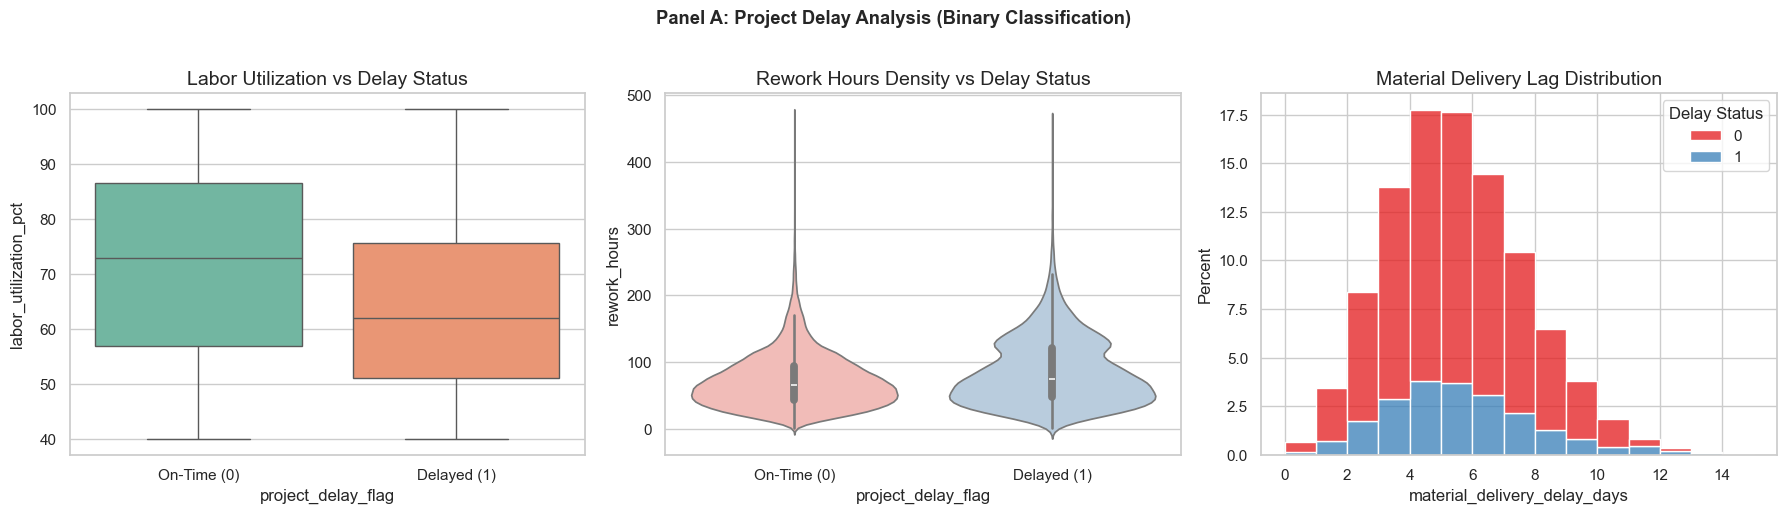

Processing Panel B: Displaying and Saving...


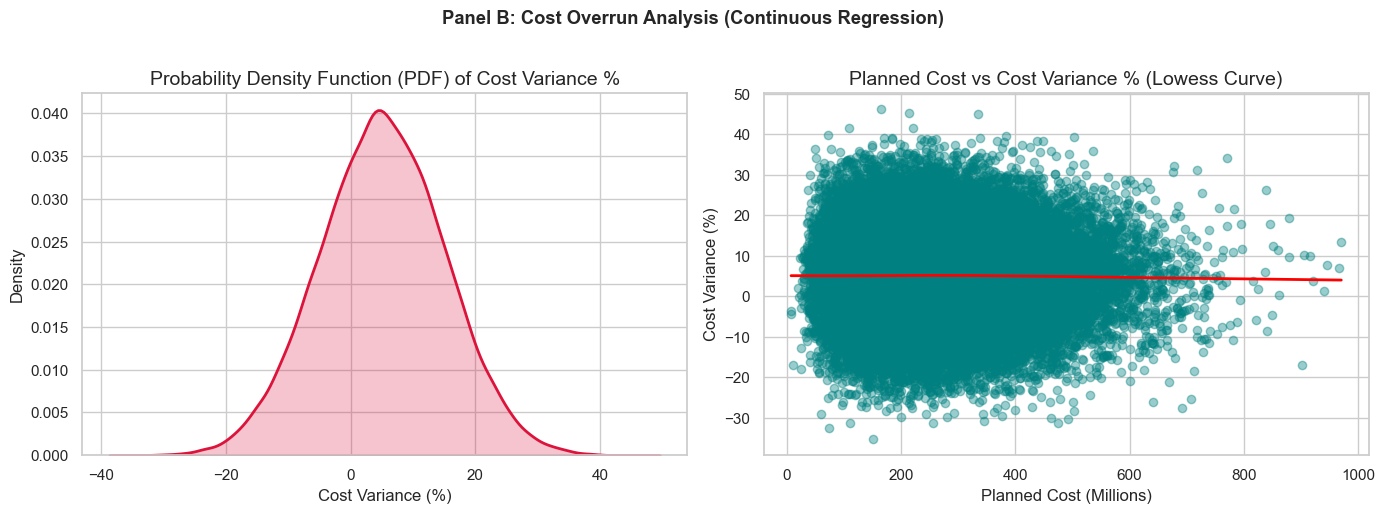

Processing Panel C: Displaying and Saving...


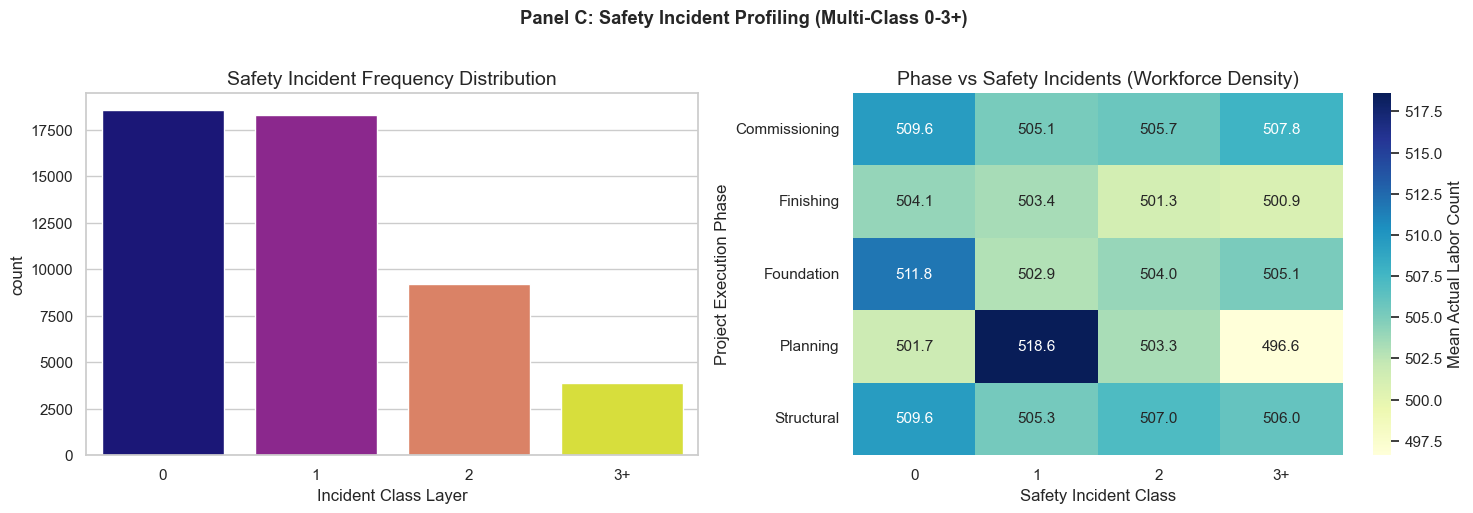

Processing Panel D Assets: Displaying and Saving...


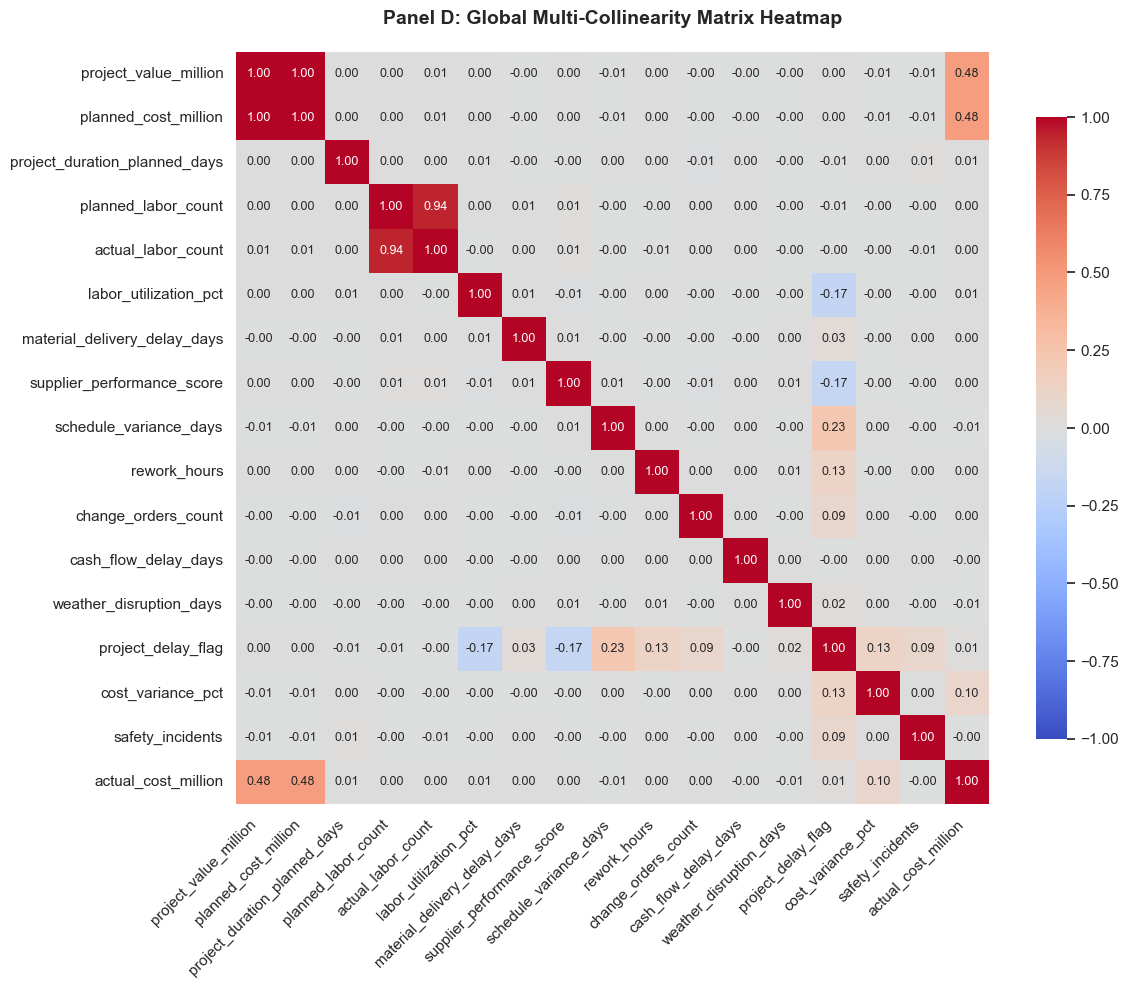

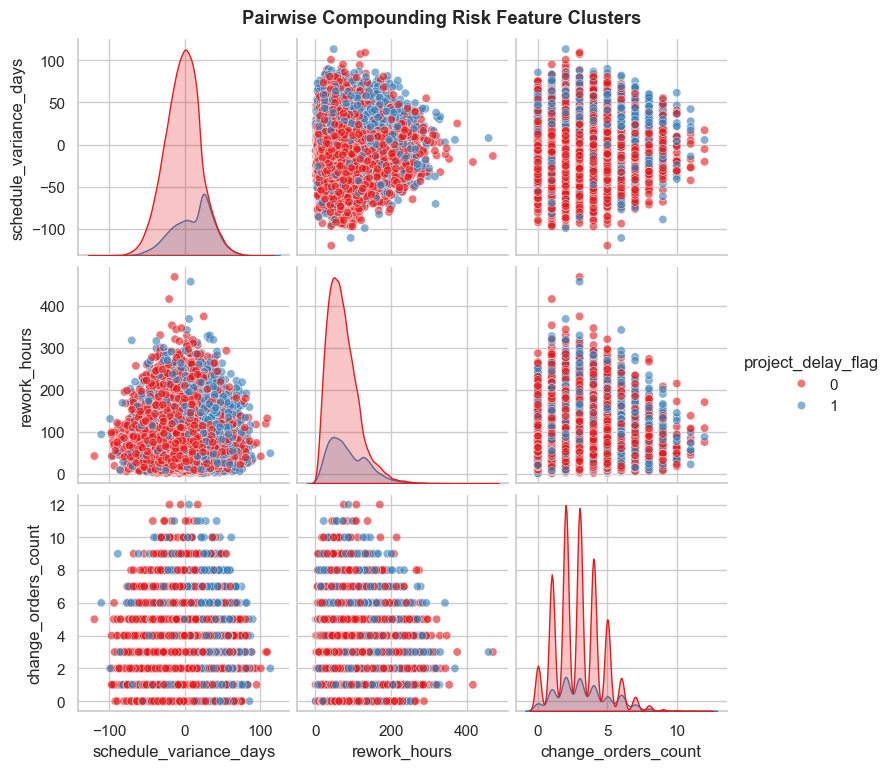

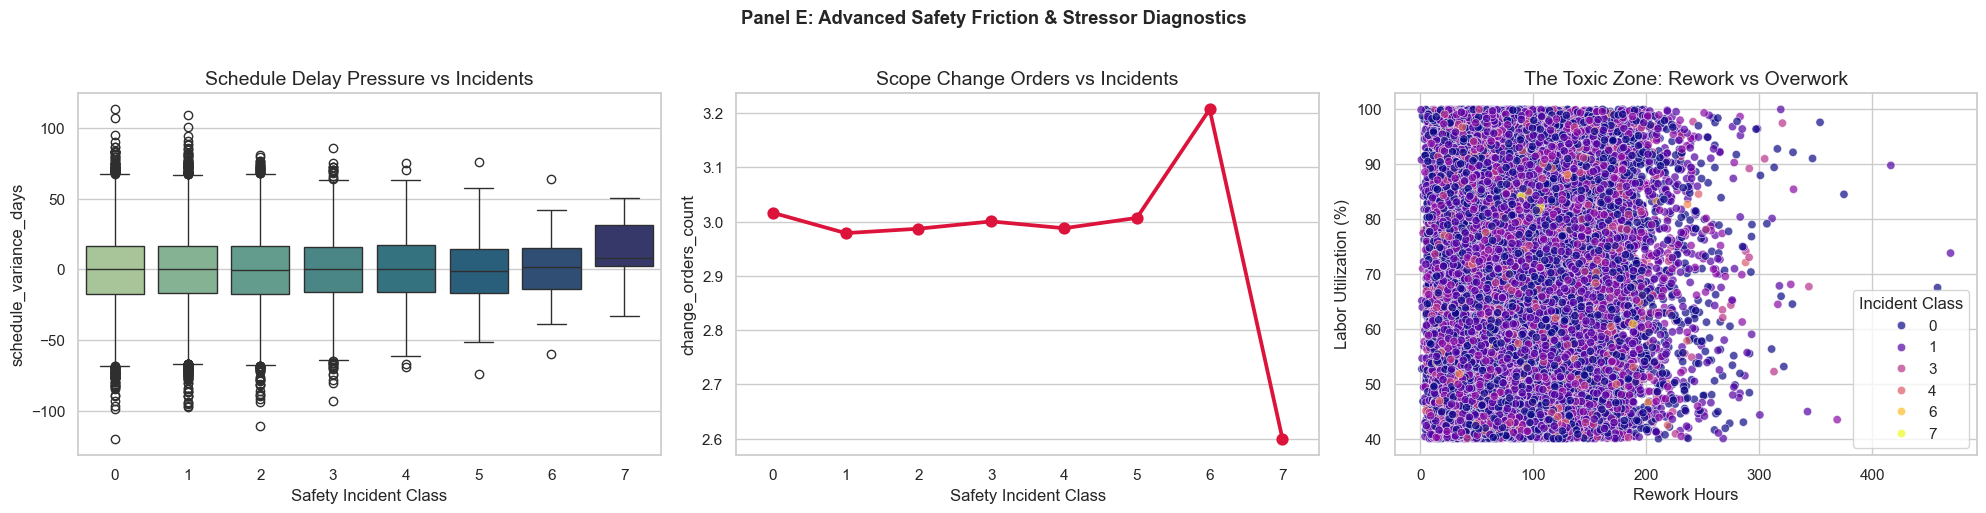

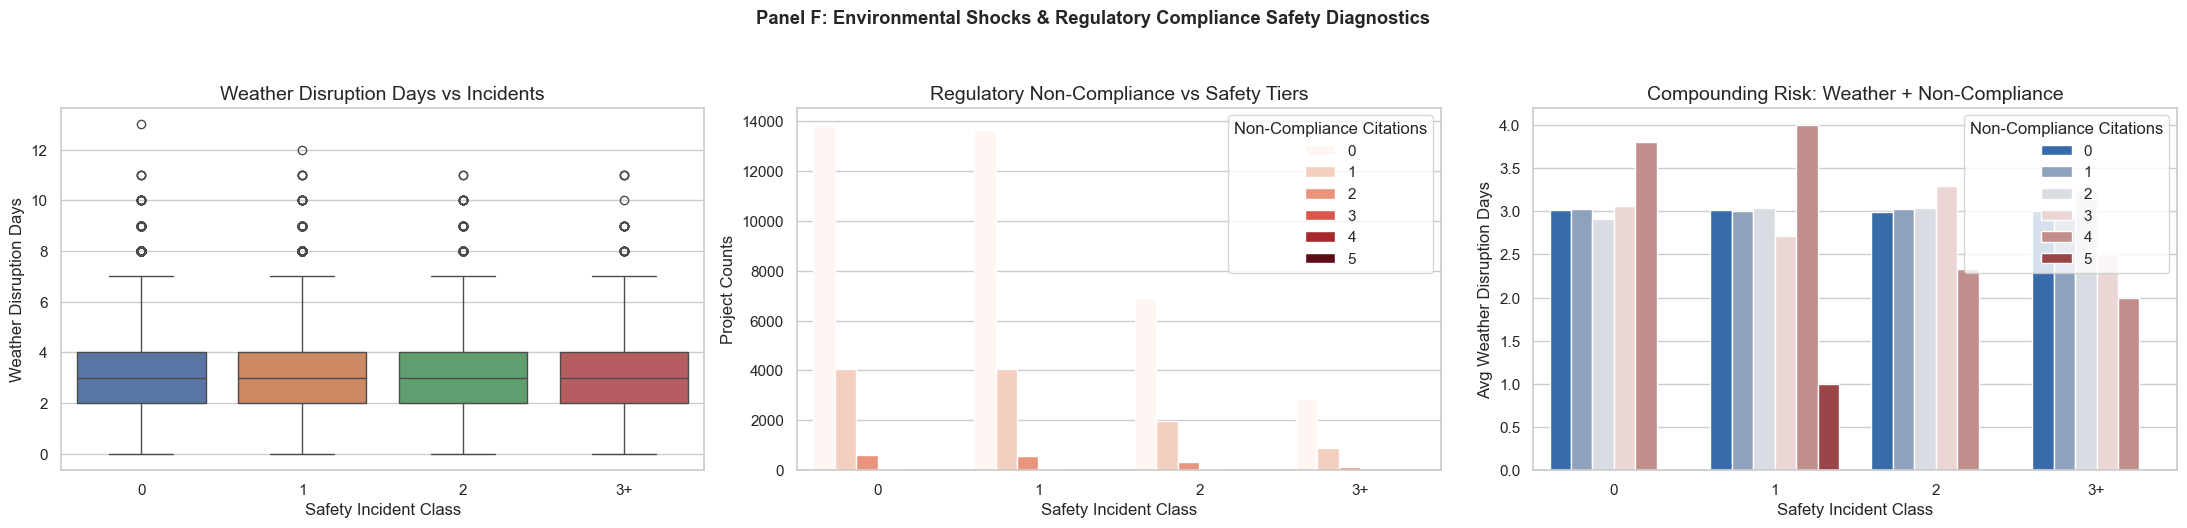

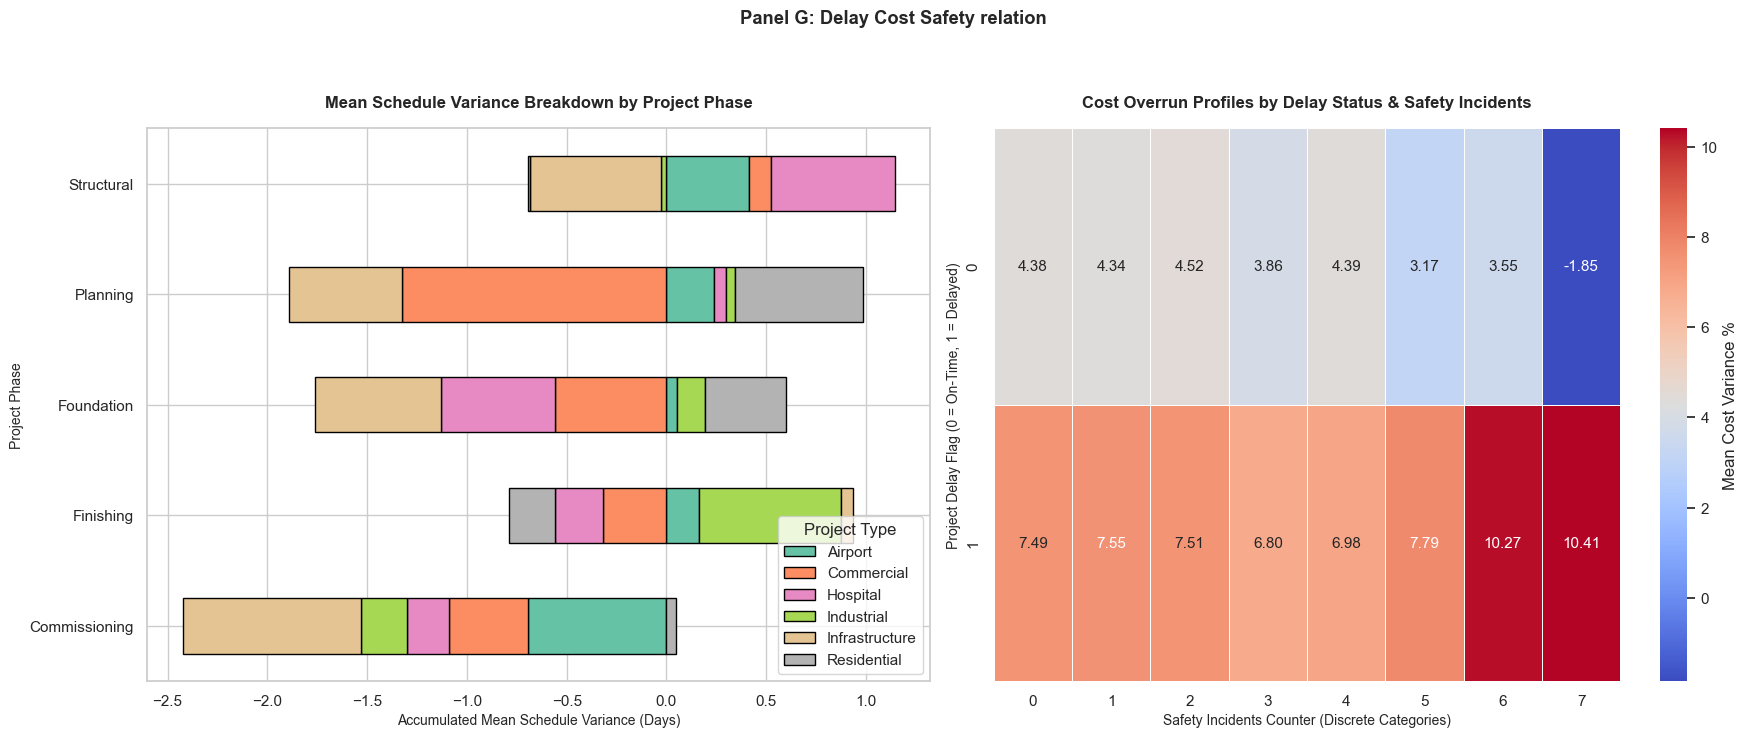


Stage 0 Run Complete. Files both displayed and written to directory standard: 'images/'


In [3]:
# Exploratory Data Analysis
def run_stage_0_eda_and_save():
    # -------------------------------------------------------------------------
    # 1. Statistical Profiling (Console Output Only)
    # -------------------------------------------------------------------------
    print("\n" + "="*70)
    print("STATIONARY STATISTICAL PROFILING (MEAN & VARIANCE)")
    print("="*70)
    
    feature_groupings = {
        "1. Scale and Valuation Baseline Dimensions": ['project_value_million', 'planned_cost_million', 'project_duration_planned_days', 'cost_variance_pct'],
        "2. Workforce Allocation and Efficiency Dynamics": ['planned_labor_count', 'actual_labor_count', 'labor_utilization_pct', 'contractor_count'],
        "3. Supply Chain and Material Procurement Metrics": ['material_delivery_delay_days', 'supplier_performance_score', 'procurement_change_requests'],
        "4. Schedule Execution and Friction Progress Trackers": ['task_completion_pct', 'schedule_variance_days', 'rework_hours', 'change_orders_count', 'cash_flow_delay_days', 'project_delay_flag'],
        "5. Environmental and Risk Constraint Profiles": ['weather_disruption_days', 'regulatory_non_compliance_count', 'client_escalations', 'safety_incidents']
    }

    for group_name, features in feature_groupings.items():
        print(f"\n{group_name}:")
        print(f"{'-'*len(group_name)}")
        available_features = [f for f in features if f in df.columns]
        if available_features:
            stats = df[available_features].agg(['mean', 'var']).T
            stats.columns = ['Mean (\u03bc)', 'Variance (\u03c3\u00b2)']
            print(stats.to_string())

    # -------------------------------------------------------------------------
    # 2. Panel A: Project Delay Analysis
    # -------------------------------------------------------------------------
    print("\nProcessing Panel A: Displaying and Saving...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Panel A: Project Delay Analysis (Binary Classification)", weight='bold', y=1.02)
    
    if 'labor_utilization_pct' in df.columns and 'project_delay_flag' in df.columns:
        sns.boxplot(ax=axes[0], data=df, x='project_delay_flag', y='labor_utilization_pct', hue='project_delay_flag', palette="Set2", legend=False)
        axes[0].set_title("Labor Utilization vs Delay Status")
        axes[0].set_xticks([0, 1])
        axes[0].set_xticklabels(['On-Time (0)', 'Delayed (1)'])
        
    if 'rework_hours' in df.columns and 'project_delay_flag' in df.columns:
        sns.violinplot(ax=axes[1], data=df, x='project_delay_flag', y='rework_hours', hue='project_delay_flag', palette="Pastel1", legend=False)
        axes[1].set_title("Rework Hours Density vs Delay Status")
        axes[1].set_xticks([0, 1])
        axes[1].set_xticklabels(['On-Time (0)', 'Delayed (1)'])

    if 'material_delivery_delay_days' in df.columns and 'project_delay_flag' in df.columns:
        sns.histplot(ax=axes[2], data=df, x='material_delivery_delay_days', hue='project_delay_flag', multiple="stack", stat="percent", binwidth=1, palette="Set1", kde=False)
        axes[2].set_title("Material Delivery Lag Distribution")
        axes[2].get_legend().set_title("Delay Status")
        
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "panel_a_delays.png"), dpi=300, bbox_inches='tight')
    plt.show()  # Display right after saving to preserve active canvas metadata
    plt.close()

    # -------------------------------------------------------------------------
    # 3. Panel B: Cost Overrun Analysis
    # -------------------------------------------------------------------------
    print("Processing Panel B: Displaying and Saving...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Panel B: Cost Overrun Analysis (Continuous Regression)", weight='bold', y=1.02)
    
    if 'cost_variance_pct' in df.columns:
        sns.kdeplot(ax=axes[0], data=df, x='cost_variance_pct', fill=True, color="crimson", lw=2)
        axes[0].set_title("Probability Density Function (PDF) of Cost Variance %")
        axes[0].set_xlabel("Cost Variance (%)")

    if 'planned_cost_million' in df.columns and 'cost_variance_pct' in df.columns:
        sns.regplot(ax=axes[1], data=df, x='planned_cost_million', y='cost_variance_pct', lowess=True, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red', 'lw':2})
        axes[1].set_title("Planned Cost vs Cost Variance % (Lowess Curve)")
        axes[1].set_ylabel("Cost Variance (%)")
        axes[1].set_xlabel("Planned Cost (Millions)")
        
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "panel_b_costs.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # -------------------------------------------------------------------------
    # 4. Panel C: Safety Incident Profiling
    # -------------------------------------------------------------------------
    print("Processing Panel C: Displaying and Saving...")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("Panel C: Safety Incident Profiling (Multi-Class 0-3+)", weight='bold', y=1.02)
    
    if 'safety_incidents' in df.columns:
        df['safety_incidents_clean'] = np.clip(df['safety_incidents'], 0, 3)
        sns.countplot(ax=axes[0], data=df, x='safety_incidents_clean', hue='safety_incidents_clean', palette="plasma", legend=False)
        axes[0].set_title("Safety Incident Frequency Distribution")
        axes[0].set_xlabel("Incident Class Layer")
        axes[0].set_xticks([0, 1, 2, 3])
        axes[0].set_xticklabels(['0', '1', '2', '3+'])

    if 'project_phase' in df.columns and 'safety_incidents' in df.columns and 'actual_labor_count' in df.columns:
        pivot_table = df.pivot_table(values='actual_labor_count', index='project_phase', columns='safety_incidents_clean', aggfunc='mean')
        sns.heatmap(ax=axes[1], data=pivot_table, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Mean Actual Labor Count'})
        axes[1].set_title("Phase vs Safety Incidents (Workforce Density)")
        axes[1].set_xlabel("Safety Incident Class")
        axes[1].set_ylabel("Project Execution Phase")
        axes[1].set_xticks(np.arange(len(pivot_table.columns)) + 0.5)
        axes[1].set_xticklabels(['0', '1', '2', '3+'])

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "panel_c_safety.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # -------------------------------------------------------------------------
    # 5. Panel D: Multivariate Risk Prediction & Collinearity Heatmap
    # -------------------------------------------------------------------------
    print("Processing Panel D Assets: Displaying and Saving...")
    continuous_cols = [
        'project_value_million', 'planned_cost_million', 'project_duration_planned_days',
        'planned_labor_count', 'actual_labor_count', 'labor_utilization_pct',
        'material_delivery_delay_days', 'supplier_performance_score', 'schedule_variance_days',
        'rework_hours', 'change_orders_count', 'cash_flow_delay_days', 'weather_disruption_days',
        'project_delay_flag', 'cost_variance_pct', 'safety_incidents', 'actual_cost_million'
    ]
    available_continuous = [c for c in continuous_cols if c in df.columns]
    
    if available_continuous:
        plt.figure(figsize=(12, 10))
        corr_matrix = df[available_continuous].corr(method='pearson')
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 9})
        plt.title("Panel D: Global Multi-Collinearity Matrix Heatmap", weight='bold', pad=20)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "panel_d_collinearity.png"), dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        risk_subset = ['schedule_variance_days', 'rework_hours', 'change_orders_count']
        available_subset = [r for r in risk_subset if r in df.columns]
        if available_subset and 'project_delay_flag' in df.columns:
            plot = sns.pairplot(df, vars=available_subset, hue='project_delay_flag', palette="Set1", diag_kind="kde", plot_kws={'alpha': 0.6})
            plot.fig.suptitle("Pairwise Compounding Risk Feature Clusters", y=1.02, weight='bold')
            plot.savefig(os.path.join(output_dir, "panel_d_pairplot.png"), dpi=300, bbox_inches='tight')
            plt.show()
            plt.close()

    # -------------------------------------------------------------------------
    # 6. Panel E: Advanced Safety Friction
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle("Panel E: Advanced Safety Friction & Stressor Diagnostics", weight='bold', y=1.02)
    sns.boxplot(ax=axes[0], data=df, x='safety_incidents', y='schedule_variance_days', hue='safety_incidents', palette="crest", legend=False)
    axes[0].set_title("Schedule Delay Pressure vs Incidents")
    axes[0].set_xlabel("Safety Incident Class")
    sns.pointplot(ax=axes[1], data=df, x='safety_incidents', y='change_orders_count', color="crimson", errorbar=None)
    axes[1].set_title("Scope Change Orders vs Incidents")
    axes[1].set_xlabel("Safety Incident Class")
    sns.scatterplot(ax=axes[2], data=df, x='rework_hours', y='labor_utilization_pct', hue='safety_incidents', palette="plasma", alpha=0.7)
    axes[2].set_title("The Toxic Zone: Rework vs Overwork")
    axes[2].set_xlabel("Rework Hours")
    axes[2].set_ylabel("Labor Utilization (%)")
    axes[2].get_legend().set_title("Incident Class")
    plt.tight_layout()
    plt.savefig("images/panel_e_advanced_safety_friction.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    
    # -------------------------------------------------------------------------
    # 7. Panel F: Environmental and regulatory safety canvas
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    fig.suptitle("Panel F: Environmental Shocks & Regulatory Compliance Safety Diagnostics", weight='bold', y=1.05)

    if 'safety_incidents' in df.columns and 'weather_disruption_days' in df.columns:
        df['safety_incidents_clean'] = np.clip(df['safety_incidents'], 0, 3)
        sns.boxplot(ax=axes[0], data=df, x='safety_incidents_clean', y='weather_disruption_days', 
                    hue='safety_incidents_clean', palette="deep", legend=False)
        axes[0].set_title("Weather Disruption Days vs Incidents")
        axes[0].set_xlabel("Safety Incident Class")
        axes[0].set_ylabel("Weather Disruption Days")
        axes[0].set_xticklabels(['0', '1', '2', '3+'])
    
    if 'safety_incidents_clean' in df.columns and 'regulatory_non_compliance_count' in df.columns:
        sns.countplot(ax=axes[1], data=df, x='safety_incidents_clean', hue='regulatory_non_compliance_count', palette="Reds")
        axes[1].set_title("Regulatory Non-Compliance vs Safety Tiers")
        axes[1].set_xlabel("Safety Incident Class")
        axes[1].set_ylabel("Project Counts")
        axes[1].set_xticklabels(['0', '1', '2', '3+'])
        axes[1].get_legend().set_title("Non-Compliance Citations")
    
    if 'safety_incidents_clean' in df.columns and 'weather_disruption_days' in df.columns and 'regulatory_non_compliance_count' in df.columns:
        sns.barplot(ax=axes[2], data=df, x='safety_incidents_clean', y='weather_disruption_days', 
                    hue='regulatory_non_compliance_count', palette="vlag", errorbar=None)
        axes[2].set_title("Compounding Risk: Weather + Non-Compliance")
        axes[2].set_xlabel("Safety Incident Class")
        axes[2].set_ylabel("Avg Weather Disruption Days")
        axes[2].set_xticklabels(['0', '1', '2', '3+'])
        axes[2].get_legend().set_title("Non-Compliance Citations")
    
    plt.tight_layout()
    plt.savefig("images/panel_f_environmental_regulatory_safety_friction.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # ------------------------------------------------------------------
    # 8. Panel G: Aggregating schedule_variance_days by project_phase, cross-cut by project_type
    # ------------------------------------------------------------------
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle("Panel G: Delay Cost Safety relation", weight='bold', y=1.05)
    schedule_pivot = df.pivot_table(
        index='project_phase', 
        columns='project_type', 
        values='schedule_variance_days', 
        aggfunc='mean'
    )
    schedule_pivot.plot(kind='barh', stacked=True, ax=ax1, cmap='Set2', edgecolor='black')
    ax1.set_title('Mean Schedule Variance Breakdown by Project Phase', fontsize=12, fontweight='bold', pad=15)
    ax1.set_xlabel('Accumulated Mean Schedule Variance (Days)', fontsize=10)
    ax1.set_ylabel('Project Phase', fontsize=10)
    ax1.legend(title='Project Type', loc='lower right')
    
    risk_pivot = df.pivot_table(
        index='project_delay_flag', 
        columns='safety_incidents', 
        values='cost_variance_pct', 
        aggfunc='mean'
    )
    
    sns.heatmap(
        data=risk_pivot, 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f", 
        linewidths=0.5,
        cbar_kws={'label': 'Mean Cost Variance %'},
        ax=ax2
    )
    
    ax2.set_title('Cost Overrun Profiles by Delay Status & Safety Incidents', fontsize=12, fontweight='bold', pad=15)
    ax2.set_xlabel('Safety Incidents Counter (Discrete Categories)', fontsize=10)
    ax2.set_ylabel('Project Delay Flag (0 = On-Time, 1 = Delayed)', fontsize=10)
    
    # 3. Finalize plot layout settings for crisp local visualization
    plt.tight_layout()
    plt.savefig("images/panel_g_delay cost safety relation.png", dpi=300, bbox_inches='tight')
    plt.show()
            
    print(f"\nStage 0 Run Complete. Files both displayed and written to directory standard: '{output_dir}/'")

if __name__ == "__main__":
    run_stage_0_eda_and_save()

In [3]:
na_counts = df.isna().sum()

# Filter to show only columns where the count is greater than 0
na_counts = na_counts[na_counts > 0]

print(na_counts)

# There are ~10000 rows with na, so dropping them will lead to 20% loss of data. So replacing them with median, but also adding indicator column for algos like XGBoost, Randomforst to know that it is replaced with median to not misinterpret

supplier_performance_score    5011
cash_flow_delay_days          4947
dtype: int64


# Pre-processing and Feature Engineering

In [4]:
# 1.1 PRIMARY DATA CLEANING & PURGING (UPDATED)
# Deduplicate first to secure unique project IDs
df_engineered = df.drop_duplicates(subset=['project_id'], keep='first').copy()

# Normalize text as originally mandated
categorical_cols_to_standardize = ['project_type', 'region', 'project_phase']
for col in categorical_cols_to_standardize:
    if col in df_engineered.columns:
        df_engineered[col] = df_engineered[col].astype(str).str.lower().str.strip()

# REMOVED: df_engineered.dropna() -> We are now preserving the 10,000 rows with missing entries
df_engineered['labor_discrepancy_index'] = (
    df_engineered['actual_labor_count'] - df_engineered['planned_labor_count']
)

df_engineered['supply_chain_vulnerability_index'] = (
    df_engineered['material_delivery_delay_days'] * df_engineered['critical_material_shortage_flag']
)

# 1.3 ANTI-LEAKAGE & ADMINISTRATIVE FILTERING
target_columns = ['project_delay_flag', 'cost_variance_pct', 'safety_incidents']
leakage_filters = ['actual_cost_million', 'penalty_cost_million']
admin_filters = ['project_id', 'legacy_project_code', 'reporting_batch_id', 'regional_cluster_id', 'administrative_reference']

columns_to_drop = leakage_filters + admin_filters + target_columns
X = df_engineered.drop(columns=[col for col in columns_to_drop if col in df_engineered.columns])

# Separate target tracking
y_delay = df_engineered['project_delay_flag'] if 'project_delay_flag' in df_engineered.columns else None
y_cost = df_engineered['cost_variance_pct'] if 'cost_variance_pct' in df_engineered.columns else None
y_safety = df_engineered['safety_incidents'] if 'safety_incidents' in df_engineered.columns else None


# Categorize features
numerical_features = [
    'project_value_million', 'planned_cost_million', 'project_duration_planned_days',
    'planned_labor_count', 'actual_labor_count', 'labor_utilization_pct', 'contractor_count',
    'material_delivery_delay_days', 'supplier_performance_score', 'procurement_change_requests',
    'task_completion_pct', 'schedule_variance_days', 'rework_hours', 'change_orders_count',
    'cash_flow_delay_days', 'weather_disruption_days', 'regulatory_non_compliance_count', 
    'client_escalations'
]
synthetic_risk_features = [
    'labor_discrepancy_index', 'supply_chain_vulnerability_index'
]
numerical_features.extend(synthetic_risk_features)

binary_indicators = ['critical_material_shortage_flag', 'extreme_weather_flag']
numerical_features.extend([col for col in binary_indicators if col in X.columns])

categorical_features = ['project_type', 'region', 'project_phase']

# ==========================================
# 1.4 PIPELINE-WRAPPED TRANSFORMATION WITH IMPUTER
# ==========================================

# Create a dedicated pipeline for numerical columns: Impute first, then scale
numerical_pipeline = Pipeline(steps=[
    # Imputes median and dynamically generates a new binary column tracking missing status
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    # Scale parameters safely using IQR to handle preserved outliers
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        # Apply the new imputation + scaling sub-pipeline to continuous trackers
        ('num', numerical_pipeline, [col for col in numerical_features if col in X.columns]),
        # Handle structural text categories natively
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), [col for col in categorical_features if col in X.columns])
    ],
    remainder='drop'
)

# Execute the local pipeline baseline
X_processed = preprocessor.fit_transform(X)

print(f"Stage 1 and 2 Complete. Preserved rows layout shape: {X_processed.shape}")


# 1. Extract the newly generated column names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

# 2. Reconstruct a clean, labeled Pandas DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

# View the new column headers (e.g., 'num__labor_discrepancy_index', 'cat__region_commercial')
print(X_processed_df.columns.tolist())

X_processed_df.to_csv(file_path, index=False)
print(f"File successfully saved to: {file_path}")


Stage 1 and 2 Complete. Preserved rows layout shape: (50000, 40)
['num__project_value_million', 'num__planned_cost_million', 'num__project_duration_planned_days', 'num__planned_labor_count', 'num__actual_labor_count', 'num__labor_utilization_pct', 'num__contractor_count', 'num__material_delivery_delay_days', 'num__supplier_performance_score', 'num__procurement_change_requests', 'num__task_completion_pct', 'num__schedule_variance_days', 'num__rework_hours', 'num__change_orders_count', 'num__cash_flow_delay_days', 'num__weather_disruption_days', 'num__regulatory_non_compliance_count', 'num__client_escalations', 'num__labor_discrepancy_index', 'num__supply_chain_vulnerability_index', 'num__critical_material_shortage_flag', 'num__extreme_weather_flag', 'num__missingindicator_supplier_performance_score', 'num__missingindicator_cash_flow_delay_days', 'cat__project_type_airport', 'cat__project_type_commercial', 'cat__project_type_hospital', 'cat__project_type_industrial', 'cat__project_type_i

# Dimensionality Reduction

In [5]:
# =====================================================================
# 3.1 LINEAR COMPRESSION VIA PRINCIPAL COMPONENT ANALYSIS (PCA)
# =====================================================================
# Instantiate PCA using automated thresholding to retain 95% of total variance
pca_transformer = PCA(n_components=0.95, random_state=42)

# Fit and transform the high-dimensional matrix
X_pca = pca_transformer.fit_transform(X_processed)

print("--- 3.1 PCA Linear Compression Complete ---")
print(f"Original feature space dimensions: {X_processed.shape[1]}")
print(f"Reduced PCA component dimension count: {X_pca.shape[1]}")
print(f"Total variance preserved across orthogonal layers: {np.sum(pca_transformer.explained_variance_ratio_):.4f}")


# =====================================================================
# 3.2 NON-LINEAR BOTTLENECK EXTRACTION (UNDERCOMPLETE AUTOENCODER)
# =====================================================================
# Convert the processed matrix into PyTorch floating-point tensors
X_tensor = torch.tensor(X_processed, dtype=torch.float32)

# Create an unindexed TensorDataset and wrapped DataLoader for local CPU batching
ae_dataset = TensorDataset(X_tensor)
ae_dataloader = DataLoader(ae_dataset, batch_size=256, shuffle=True)

class UndercompleteAutoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=8):
        super(UndercompleteAutoencoder, self).__init__()
        
        # Encoder Module: Progressively compresses 43 features down to an 8-node latent core
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, bottleneck_dim)  # Core dense bottleneck layer
        )
        
        # Decoder Module: Maps the 8 core latent coordinates back to original input sizing
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
        
    def forward(self, x):
        latent_space = self.encoder(x)
        reconstruction = self.decoder(latent_space)
        return reconstruction

# Force local on-premise execution strictly on CPU hardware layers
device = torch.device("cpu")
autoencoder = UndercompleteAutoencoder(input_dim=X_processed.shape[1], bottleneck_dim=8).to(device)

# Define unsupervised reconstruction error tracking criteria and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.005)

# Initialize unsupervised local CPU training phase
epochs = 15
autoencoder.train()
print("\n--- 3.2 Training PyTorch Undercomplete Autoencoder Core ---")

for epoch in range(epochs):
    running_loss = 0.0
    for batch in ae_dataloader:
        inputs = batch[0].to(device)
        
        # Reset internal optimizer tracking gradients
        optimizer.zero_grad()
        
        # Execute forward pass to evaluate output reconstruction matching raw inputs
        reconstructions = autoencoder(inputs)
        loss = criterion(reconstructions, inputs)
        
        # Execute backpropagation and weight optimization steps
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(X_processed)
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Reconstruction Mean Squared Error: {epoch_loss:.6f}")


# =====================================================================
# 3.3 UNCOUPLING DECODER FOR EXTRACTION & DOWNSTREAM PREPARATION
# =====================================================================
# Lock down network settings by entering evaluation tracking mode
autoencoder.eval()

with torch.no_grad():
    # Pass input matrix X directly into the isolated encoder backbone to extract embeddings
    X_latent = autoencoder.encoder(X_tensor.to(device)).cpu().numpy()

print("\n--- 3.3 Latent Embedding Extraction Complete ---")
print(f"Dense autoencoder matrix dimensions: {X_latent.shape}")


--- 3.1 PCA Linear Compression Complete ---
Original feature space dimensions: 40
Reduced PCA component dimension count: 28
Total variance preserved across orthogonal layers: 0.9532

--- 3.2 Training PyTorch Undercomplete Autoencoder Core ---
Epoch [1/15] - Reconstruction Mean Squared Error: 0.246166
Epoch [3/15] - Reconstruction Mean Squared Error: 0.148456
Epoch [6/15] - Reconstruction Mean Squared Error: 0.145143
Epoch [9/15] - Reconstruction Mean Squared Error: 0.144212
Epoch [12/15] - Reconstruction Mean Squared Error: 0.143863
Epoch [15/15] - Reconstruction Mean Squared Error: 0.143259

--- 3.3 Latent Embedding Extraction Complete ---
Dense autoencoder matrix dimensions: (50000, 8)


In [7]:
# =====================================================================
# 3.2 NON-LINEAR BOTTLENECK EXTRACTION (OPTIMIZED AUTOENCODER)
# =====================================================================
class OptimizedUndercompleteAutoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=12):
        super(OptimizedUndercompleteAutoencoder, self).__init__()
        
        # Encoder: 43 -> 64 -> 32 -> 12 Bottleneck Layer
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, bottleneck_dim)  # Expanded 12-node latent core
        )
        
        # Decoder: 12 -> 32 -> 64 -> 43 Reconstructed Layer
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, input_dim)
        )
        
    def forward(self, x):
        latent_space = self.encoder(x)
        reconstruction = self.decoder(latent_space)
        return reconstruction

# Prepare PyTorch Tensors and DataLoader for Local CPU Execution
X_tensor = torch.tensor(X_processed, dtype=torch.float32)
ae_dataset = TensorDataset(X_tensor)
ae_dataloader = DataLoader(ae_dataset, batch_size=256, shuffle=True)

# Instantiate Network, Optimizer, Scheduler, and Outlier-Resilient Loss Function
device = torch.device("cpu")
autoencoder = OptimizedUndercompleteAutoencoder(input_dim=X_processed.shape[1], bottleneck_dim=12).to(device)

# AdamW with Weight Decay Regularization
optimizer = optim.AdamW(autoencoder.parameters(), lr=0.008, weight_decay=1e-4)

# Cosine Annealing Learning Rate Decay Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# Smooth L1 (Huber) Loss: Linear for extreme outliers, quadratic for small errors
criterion = nn.SmoothL1Loss()

epochs = 20
print("\n--- 3.2 Training Optimized PyTorch Undercomplete Autoencoder Core ---")

for epoch in range(epochs):
    autoencoder.train()
    running_loss = 0.0
    
    for batch in ae_dataloader:
        inputs = batch[0].to(device)
        
        optimizer.zero_grad()
        reconstructions = autoencoder(inputs)
        loss = criterion(reconstructions, inputs)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    scheduler.step()
    epoch_loss = running_loss / len(X_processed)
    
    if (epoch + 1) % 4 == 0 or epoch == 0 or epoch == epochs:
        print(f"Epoch [{epoch+1:02d}/{epochs}] - Reconstruction Smooth L1 Loss: {epoch_loss:.6f}")


# =====================================================================
# 3.3 UNCOUPLING DECODER & COMBINING LATENT EMBEDDINGS
# =====================================================================
autoencoder.eval()
with torch.no_grad():
    # Pass input matrix X directly into the isolated encoder branch
    X_latent = autoencoder.encoder(X_tensor.to(device)).cpu().numpy()

# Generate structured column headers for downstream model tracking
pca_cols = [f"pca_comp_{i}" for i in range(X_pca.shape[1])]
latent_cols = [f"ae_latent_{i}" for i in range(X_latent.shape[1])]
# Assemble into standardized, labeled Pandas structures for downstream tasks
df_pca_features = pd.DataFrame(X_pca, columns=pca_cols)
print(df_pca_features)
df_latent_features = pd.DataFrame(X_latent, columns=latent_cols)
print(df_latent_features)

df_modeling_base = pd.concat([df_pca_features, df_latent_features], axis=1)

# Feature matrix for Stage 4 supervised models (PCA components + AE latent embeddings)
X_combined = df_modeling_base.to_numpy(dtype=np.float32)
print(f"X_combined ready for Stage 4: {X_combined.shape}")

file_path_dimensionality_reduced = os.path.join(folder_path, "dimensionality_reduced_df.csv")

# 2. Create the folder if it does not exist
# exist_ok=True prevents an error if the directory already exists
os.makedirs(folder_path, exist_ok=True)
df_modeling_base.to_csv(file_path_dimensionality_reduced, index=False)
print(f"File successfully saved to: {file_path_dimensionality_reduced}")

# 1. Retrieve the post-processed feature names from Stage 1/2
feature_names = preprocessor.get_feature_names_out()

# 2. Extract the loadings matrix shape: (n_components, n_features)
loadings = pca_transformer.components_

# 3. Create a clean DataFrame mapping original features to components
df_loadings = pd.DataFrame(
    loadings, 
    columns=feature_names, 
    index=[f"PCA_Comp_{i}" for i in range(loadings.shape[0])]
)

# 4. View the top 5 contributing columns for the first principal component
top_features_comp0 = df_loadings.iloc[0].abs().sort_values(ascending=False).head(10)
print("Top 10 columns driving PCA Component 0:\n", top_features_comp0)
print("\n--- 3.3 Latent Embedding Extraction Complete ---")
print(f"PCA Component Dimension Count: {X_pca.shape[1]}")
print(f"Dense Autoencoder Bottleneck Dimension Count: {X_latent.shape[1]}")
print(f"Final Combined Latent Matrix Dimensions: {df_modeling_base.shape}")
print("Stage 3 Processing Finalized. Reduced dimensions are compiled and prepared for Stage 4 Modeling.")




--- 3.2 Training Optimized PyTorch Undercomplete Autoencoder Core ---
Epoch [01/20] - Reconstruction Smooth L1 Loss: 0.074627
Epoch [04/20] - Reconstruction Smooth L1 Loss: 0.054839
Epoch [08/20] - Reconstruction Smooth L1 Loss: 0.051575
Epoch [12/20] - Reconstruction Smooth L1 Loss: 0.048963
Epoch [16/20] - Reconstruction Smooth L1 Loss: 0.047018
Epoch [20/20] - Reconstruction Smooth L1 Loss: 0.046037
       pca_comp_0  pca_comp_1  pca_comp_2  pca_comp_3  pca_comp_4  pca_comp_5  \
0       -0.761708    0.378489   -0.732174   -0.319348    0.246328    0.647266   
1       -0.703394   -0.323663   -0.330080   -0.571681    0.381123   -0.928762   
2       -0.766520   -0.405221    0.223816    0.361437    0.487210    0.211568   
3       -0.751790   -0.431873    1.390901   -1.586713   -1.636266   -0.204820   
4        5.321574    1.901942   -0.441803   -0.790188    0.082319   -1.564753   
...           ...         ...         ...         ...         ...         ...   
49995   -0.720726   -1.201

# Project Delay Prediction - Binary Classification


  TASK 4.1: PROJECT DELAY PREDICTION (BINARY CLASSIFICATION)
[Random Forest] Recall: 0.6734 | F1: 0.6109 | ROC-AUC: 0.8527 | BCE: 0.3739
[Gaussian Naive Bayes] Recall: 0.4537 | F1: 0.4902 | ROC-AUC: 0.7972 | BCE: 0.8987
[XGBoost Classifier] Recall: 0.6778 | F1: 0.6179 | ROC-AUC: 0.8619 | BCE: 0.3576
[MLP Classifier (Softmax)] Recall: 0.5839 | F1: 0.5405 | ROC-AUC: 0.7920 | BCE: 0.5024


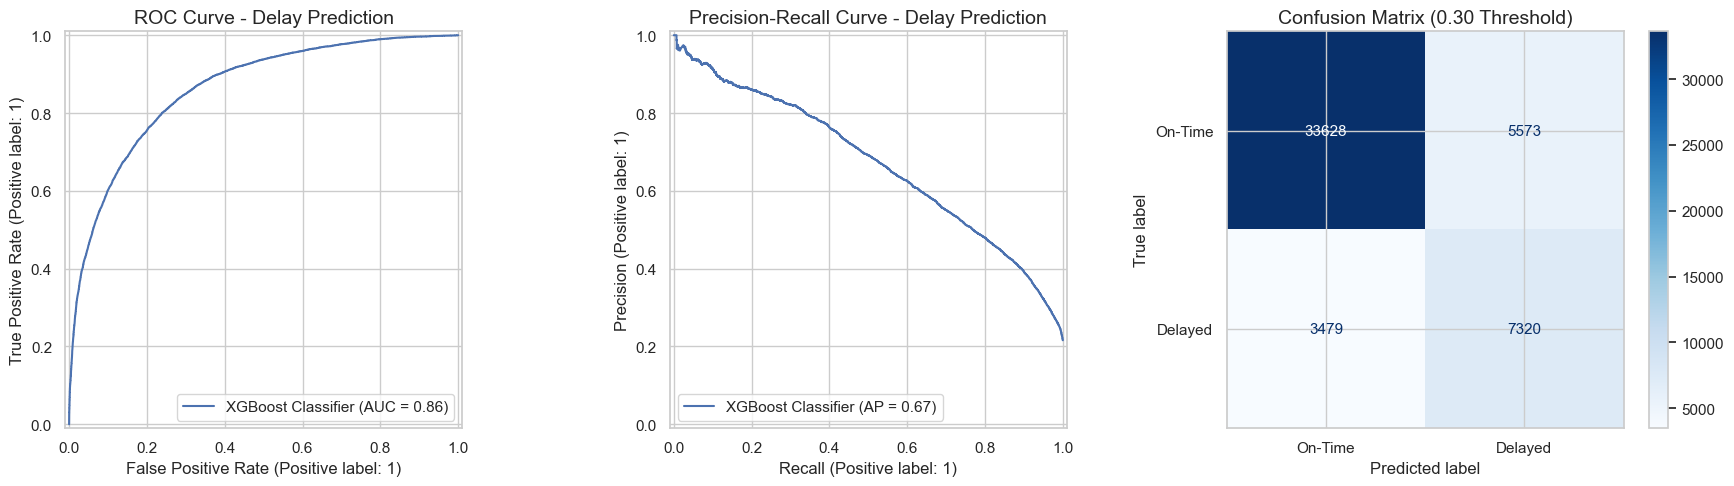

In [8]:
# Set global random seeds for local execution reproducibility
np.random.seed(42)
torch.manual_seed(42)

# =====================================================================
# TASK 4.1: PROJECT DELAY PREDICTION (BINARY CLASSIFICATION)
# =====================================================================
print("\n=======================================================")
print("  TASK 4.1: PROJECT DELAY PREDICTION (BINARY CLASSIFICATION)")
print("=======================================================")

# Enforce Softmax 2D Matrix Target Representation for Scikit-Learn MLPClassifier
# Maps [0, 1] into a 2D array [[1, 0], [0, 1]] representing [On-Time, Delayed]
y_delay_2d = np.column_stack([1 - y_delay, y_delay])

# Define Model Panel for Task 4.1
delay_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'Gaussian Naive Bayes': GaussianNB(),
    'XGBoost Classifier': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'MLP Classifier (Softmax)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=300, random_state=42)
}

# 5-Fold Stratified Cross-Validation maintaining native 78.4% / 21.6% class balance
skf_delay = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

delay_results = []

fig_delay, axes_delay = plt.subplots(1, 3, figsize=(18, 5))

for name, model in delay_models.items():
    oof_probs = np.zeros(len(y_delay))
    
    for train_idx, val_idx in skf_delay.split(X_combined, y_delay):
        X_tr, X_val = X_combined[train_idx], X_combined[val_idx]
        
        if name == 'MLP Classifier (Softmax)':
            # Train using 2D target matrix to enforce two output nodes with Softmax cross-entropy
            y_tr_2d, y_val_2d = y_delay_2d[train_idx], y_delay_2d[val_idx]
            model.fit(X_tr, y_tr_2d)
            probs = model.predict_proba(X_val)
            oof_probs[val_idx] = probs[:, 1]  # Extract probability for Delayed class
        else:
            y_tr = y_delay[train_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]
            oof_probs[val_idx] = probs
            
    oof_preds = (oof_probs >= 0.30).astype(int)  # 0.30 decision threshold optimization
    
    rec = recall_score(y_delay, oof_preds)
    f1 = f1_score(y_delay, oof_preds)
    auc = roc_auc_score(y_delay, oof_probs)
    bce = log_loss(y_delay, oof_probs)
    
    delay_results.append({'Model': name, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc, 'BCE Loss': bce})
    print(f"[{name}] Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f} | BCE: {bce:.4f}")
    
    # Plot ROC and Precision-Recall Curves for the top ensemble model
    if name == 'XGBoost Classifier':
        RocCurveDisplay.from_predictions(y_delay, oof_probs, ax=axes_delay[0], name=name)
        PrecisionRecallDisplay.from_predictions(y_delay, oof_probs, ax=axes_delay[1], name=name)
        ConfusionMatrixDisplay.from_predictions(y_delay, oof_preds, display_labels=['On-Time', 'Delayed'], ax=axes_delay[2], cmap='Blues')

axes_delay[0].set_title("ROC Curve - Delay Prediction")
axes_delay[1].set_title("Precision-Recall Curve - Delay Prediction")
axes_delay[2].set_title("Confusion Matrix (0.30 Threshold)")
plt.tight_layout()
plt.show()

df_delay_summary = pd.DataFrame(delay_results)




# Project delay - Hyperparameter tuning


  STAGE 4.1.1: LEAKAGE-SAFE PROJECT DELAY OPTIMIZATION
XGBoost | preprocessed | sigmoid | fold 1/5 complete
XGBoost | preprocessed | sigmoid | fold 2/5 complete
XGBoost | preprocessed | sigmoid | fold 3/5 complete
XGBoost | preprocessed | sigmoid | fold 4/5 complete
XGBoost | preprocessed | sigmoid | fold 5/5 complete
XGBoost | preprocessed | isotonic | fold 1/5 complete
XGBoost | preprocessed | isotonic | fold 2/5 complete
XGBoost | preprocessed | isotonic | fold 3/5 complete
XGBoost | preprocessed | isotonic | fold 4/5 complete
XGBoost | preprocessed | isotonic | fold 5/5 complete
LightGBM | preprocessed | sigmoid | fold 1/5 complete
LightGBM | preprocessed | sigmoid | fold 2/5 complete
LightGBM | preprocessed | sigmoid | fold 3/5 complete
LightGBM | preprocessed | sigmoid | fold 4/5 complete
LightGBM | preprocessed | sigmoid | fold 5/5 complete
LightGBM | preprocessed | isotonic | fold 1/5 complete
LightGBM | preprocessed | isotonic | fold 2/5 complete
LightGBM | preprocessed | iso

,model,representation,calibration,threshold,precision,recall,f1,roc_auc,bce,eligible
0,HistGradientBoosting,preprocessed,sigmoid,0.304,0.579417,0.734049,0.647631,0.878187,0.335024,False
1,LightGBM,preprocessed,isotonic,0.310,0.577849,0.730994,0.645462,0.877771,0.335381,False
2,HistGradientBoosting,preprocessed,isotonic,0.308,0.577040,0.735901,0.646860,0.877984,0.335393,False
3,LightGBM,preprocessed,sigmoid,0.302,0.576884,0.734420,0.646189,0.878220,0.335692,False
4,CatBoost,preprocessed,isotonic,0.300,0.573150,0.735716,0.644337,0.877159,0.336732,False
5,XGBoost,preprocessed,isotonic,0.310,0.574200,0.729142,0.642461,0.876672,0.337470,False
6,Random Forest,preprocessed,isotonic,0.310,0.573301,0.732938,0.643365,0.875565,0.341027,False
7,CatBoost,preprocessed,sigmoid,0.230,0.576069,0.730716,0.644242,0.877048,0.345363,False
8,XGBoost,preprocessed,sigmoid,0.254,0.578377,0.721270,0.641968,0.875371,0.345519,False
9,Random Forest,preprocessed,sigmoid,0.244,0.574645,0.730345,0.643207,0.875766,0.347212,False


No model met both hard gates (F1 > 0.70, BCE < 0.20) under leakage-safe OOF validation.


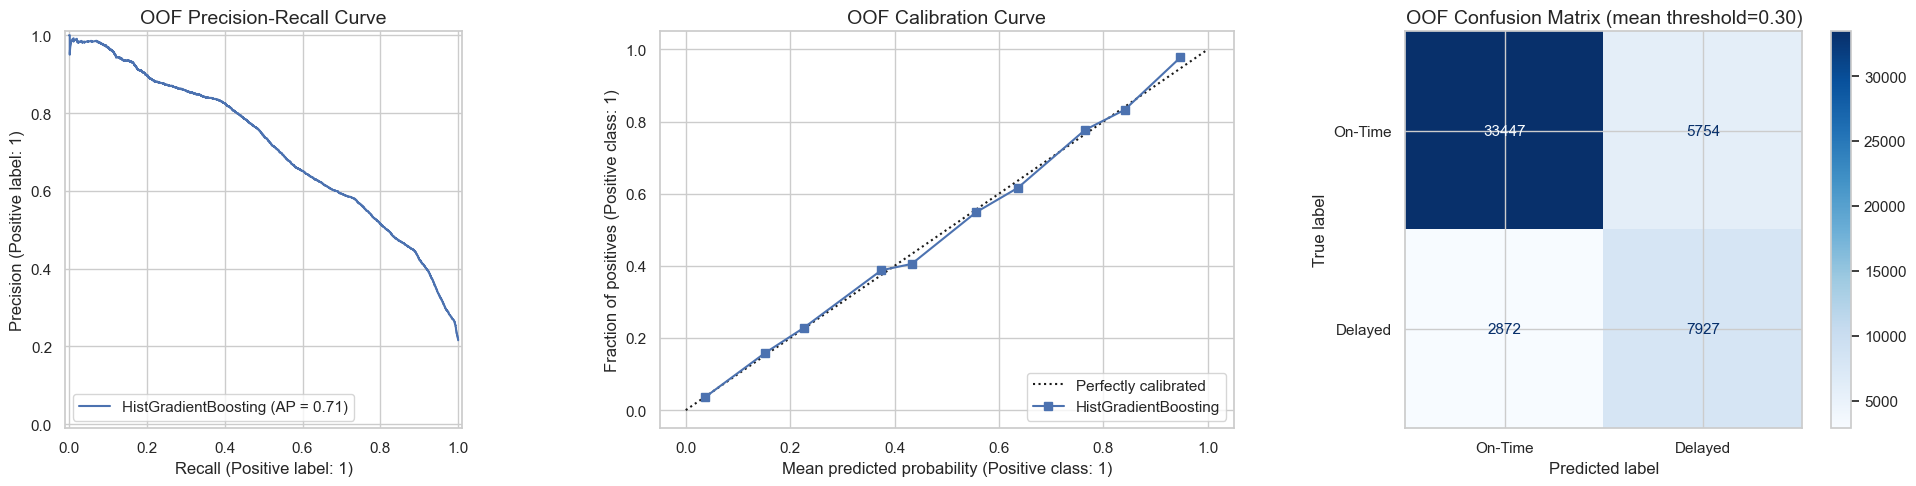


OOF equal-weight ensemble of the best distinct base models:
{'threshold': 0.3047, 'precision': 0.5771, 'recall': 0.7353, 'f1': 0.6467, 'roc_auc': 0.8781, 'bce': 0.3347, 'eligible': False}


In [9]:
print("\n=======================================================")
print("  STAGE 4.1.1: LEAKAGE-SAFE PROJECT DELAY OPTIMIZATION")
print("=======================================================")

OUTER_SPLITS = 5
INNER_SPLITS = 3
N_ITER = 10
RANDOM_STATE = 42
F1_GATE = 0.70
BCE_GATE = 0.20
THRESHOLDS = np.round(np.arange(0.20, 0.71, 0.01), 2)

outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Only fit preprocessing to training data. PCA is evaluated as a fold-local
# alternative representation; the autoencoder embedding is deliberately not
# reused because it was trained on all rows.
def make_delay_pipeline(estimator, representation):
    steps = [('preprocessor', clone(preprocessor))]
    if representation == 'pca95':
        steps.append(('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)))
    steps.append(('model', estimator))
    return Pipeline(steps)


def prefixed(params):
    return {f'model__{name}': values for name, values in params.items()}


def select_f1_threshold(y_true, probabilities):
    scores = [f1_score(y_true, probabilities >= threshold, zero_division=0) for threshold in THRESHOLDS]
    return float(THRESHOLDS[int(np.argmax(scores))])


def metric_row(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    return {
        'threshold': threshold,
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probabilities),
        'bce': log_loss(y_true, probabilities, labels=[0, 1])
    }


# Parameter distributions use conservative tree depths and explicit
# regularization because overly complex trees often worsen log loss.
MODEL_SPECS = {
    'XGBoost': {
        'estimator': XGBClassifier(
            random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1,
            tree_method='hist'
        ),
        'params': prefixed({
            'n_estimators': [200, 400, 600],
            'learning_rate': [0.01, 0.03, 0.05, 0.08],
            'max_depth': [3, 4, 5, 6],
            'min_child_weight': [1, 3, 5, 8],
            'subsample': [0.65, 0.8, 0.95],
            'colsample_bytree': [0.65, 0.8, 0.95],
            'gamma': [0.0, 0.1, 0.3],
            'reg_alpha': [0.0, 0.01, 0.1, 0.5],
            'reg_lambda': [0.5, 1.0, 2.0, 5.0],
            'scale_pos_weight': [1.0, 1.5, 2.0, 2.5, 3.0]
        })
    },
    'LightGBM': {
        'estimator': LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
        'params': prefixed({
            'n_estimators': [200, 400, 600],
            'learning_rate': [0.01, 0.03, 0.05, 0.08],
            'num_leaves': [7, 15, 31, 63],
            'max_depth': [-1, 3, 5, 7],
            'min_child_samples': [20, 40, 80, 120],
            'subsample': [0.65, 0.8, 0.95],
            'colsample_bytree': [0.65, 0.8, 0.95],
            'reg_alpha': [0.0, 0.01, 0.1, 0.5],
            'reg_lambda': [0.0, 0.5, 1.0, 3.0],
            'scale_pos_weight': [1.0, 1.5, 2.0, 2.5, 3.0]
        })
    },
    'CatBoost': {
        'estimator': CatBoostClassifier(
            random_seed=RANDOM_STATE, verbose=0, thread_count=-1,
            allow_writing_files=False, loss_function='Logloss'
        ),
        'params': prefixed({
            'iterations': [200, 400, 600],
            'depth': [4, 5, 6, 7, 8],
            'learning_rate': [0.01, 0.03, 0.05, 0.08],
            'l2_leaf_reg': [1.0, 3.0, 5.0, 10.0],
            'random_strength': [0.0, 0.25, 0.5, 1.0],
            'bagging_temperature': [0.0, 0.5, 1.0, 2.0],
            'border_count': [64, 128, 254],
            'scale_pos_weight': [1.0, 1.5, 2.0, 2.5, 3.0]
        })
    },
    'Extra Trees': {
        'estimator': ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'params': prefixed({
            'n_estimators': [300, 500, 700],
            'max_depth': [None, 10, 16, 24],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'max_features': ['sqrt', 'log2', 0.5, 0.8],
            'class_weight': [None, 'balanced', 'balanced_subsample']
        })
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'params': prefixed({
            'n_estimators': [300, 500, 700],
            'max_depth': [None, 10, 16, 24],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
            'class_weight': [None, 'balanced', 'balanced_subsample']
        })
    },
    'HistGradientBoosting': {
        'estimator': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': prefixed({
            'learning_rate': [0.02, 0.04, 0.06, 0.1],
            'max_iter': [200, 400, 600],
            'max_leaf_nodes': [7, 15, 31, 63],
            'max_depth': [None, 3, 5, 7],
            'min_samples_leaf': [10, 20, 40, 80],
            'l2_regularization': [0.0, 0.01, 0.1, 1.0]
        })
    }
}


def nested_calibrated_oof(model_name, spec, representation, calibration_method):
    """Return unbiased outer-fold probabilities and fold-local thresholds."""
    outer_probabilities = np.zeros(len(y_delay), dtype=float)
    outer_thresholds = []
    best_parameters = []

    for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X, y_delay), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y_delay.iloc[train_idx], y_delay.iloc[valid_idx]
        inner_cv = StratifiedKFold(
            n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE + fold
        )

        search = RandomizedSearchCV(
            estimator=make_delay_pipeline(clone(spec['estimator']), representation),
            param_distributions=spec['params'],
            n_iter=N_ITER,
            scoring={'f1': 'f1', 'neg_log_loss': 'neg_log_loss'},
            refit='neg_log_loss',
            cv=inner_cv,
            random_state=RANDOM_STATE + fold,
            n_jobs=1,
            verbose=0
        )
        search.fit(X_train, y_train)
        best_parameters.append(search.best_params_)

        # Select calibration and the decision threshold using outer-training rows only.
        train_calibrator = CalibratedClassifierCV(
            estimator=clone(search.best_estimator_), method=calibration_method,
            cv=inner_cv, n_jobs=1
        )
        train_oof_probabilities = cross_val_predict(
            train_calibrator, X_train, y_train, cv=inner_cv,
            method='predict_proba', n_jobs=1
        )[:, 1]
        outer_thresholds.append(select_f1_threshold(y_train.to_numpy(), train_oof_probabilities))

        final_calibrator = clone(train_calibrator).fit(X_train, y_train)
        outer_probabilities[valid_idx] = final_calibrator.predict_proba(X_valid)[:, 1]
        print(f'{model_name} | {representation} | {calibration_method} | fold {fold}/{OUTER_SPLITS} complete')

    # Each validation row is assigned a threshold selected without its label.
    fold_thresholds = np.zeros(len(y_delay), dtype=float)
    for threshold, (_, valid_idx) in zip(outer_thresholds, outer_cv.split(X, y_delay)):
        fold_thresholds[valid_idx] = threshold
    fold_predictions = (outer_probabilities >= fold_thresholds).astype(int)

    metrics = {
        'model': model_name,
        'representation': representation,
        'calibration': calibration_method,
        'threshold': float(np.mean(outer_thresholds)),
        'precision': precision_score(y_delay, fold_predictions, zero_division=0),
        'recall': recall_score(y_delay, fold_predictions, zero_division=0),
        'f1': f1_score(y_delay, fold_predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_delay, outer_probabilities),
        'bce': log_loss(y_delay, outer_probabilities, labels=[0, 1]),
        'fold_thresholds': outer_thresholds,
        'best_parameters': best_parameters,
        'probabilities': outer_probabilities,
        'predictions': fold_predictions
    }
    return metrics


# The raw preprocessed representation is the primary comparison. PCA is tested
# only for linear/nonlinear models where compression may reduce noise.
search_jobs = []
for name, spec in MODEL_SPECS.items():
    representations = ['preprocessed', 'pca95'] if name in {'Extra Trees', 'Random Forest', 'HistGradientBoosting'} else ['preprocessed']
    for representation in representations:
        for method in ('sigmoid', 'isotonic'):
            search_jobs.append((name, spec, representation, method))

all_delay_runs = []
for name, spec, representation, method in search_jobs:
    all_delay_runs.append(nested_calibrated_oof(name, spec, representation, method))

# Keep long arrays out of the display table while retaining them for diagnostics.
delay_leaderboard = pd.DataFrame([
    {key: value for key, value in run.items() if key not in {'probabilities', 'predictions', 'fold_thresholds', 'best_parameters'}}
    for run in all_delay_runs
]).sort_values(['bce', 'f1'], ascending=[True, False]).reset_index(drop=True)
delay_leaderboard['eligible'] = (
    (delay_leaderboard['f1'] > F1_GATE) & (delay_leaderboard['bce'] < BCE_GATE)
)

print('\nLeakage-safe OOF leaderboard:')
display(delay_leaderboard)

eligible_delay_models = delay_leaderboard[delay_leaderboard['eligible']]
if eligible_delay_models.empty:
    print(f'No model met both hard gates (F1 > {F1_GATE:.2f}, BCE < {BCE_GATE:.2f}) under leakage-safe OOF validation.')
else:
    print('Eligible models meeting both hard gates:')
    display(eligible_delay_models)

# Select the strongest OOF run for diagnostics. The ranking favours BCE because
# thresholding cannot improve probability calibration, then breaks ties by F1.
best_row = delay_leaderboard.iloc[0]
best_run = next(
    run for run in all_delay_runs
    if run['model'] == best_row['model']
    and run['representation'] == best_row['representation']
    and run['calibration'] == best_row['calibration']
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
PrecisionRecallDisplay.from_predictions(y_delay, best_run['probabilities'], ax=axes[0], name=best_run['model'])
axes[0].set_title('OOF Precision-Recall Curve')
CalibrationDisplay.from_predictions(y_delay, best_run['probabilities'], n_bins=10, ax=axes[1], name=best_run['model'])
axes[1].set_title('OOF Calibration Curve')
ConfusionMatrixDisplay.from_predictions(y_delay, best_run['predictions'], display_labels=['On-Time', 'Delayed'], cmap='Blues', ax=axes[2])
axes[2].set_title(f"OOF Confusion Matrix (mean threshold={best_run['threshold']:.2f})")
plt.tight_layout()
plt.show()

# Evaluate a fixed equal-weight ensemble of the three best distinct base models.
# The blend weights are fixed before scoring, and its threshold is the mean of
# fold-local thresholds already selected without each validation fold's labels.
top_runs = []
seen_models = set()
for run in sorted(all_delay_runs, key=lambda run: (run['bce'], -run['f1'])):
    if run['model'] not in seen_models:
        top_runs.append(run)
        seen_models.add(run['model'])
    if len(top_runs) == 3:
        break

if len(top_runs) >= 2:
    ensemble_probabilities = np.mean([run['probabilities'] for run in top_runs], axis=0)
    ensemble_threshold = float(np.mean([run['threshold'] for run in top_runs]))
    ensemble_metrics = metric_row(y_delay, ensemble_probabilities, ensemble_threshold)
    ensemble_metrics['eligible'] = (
        ensemble_metrics['f1'] > F1_GATE and ensemble_metrics['bce'] < BCE_GATE
    )
    print('\nOOF equal-weight ensemble of the best distinct base models:')
    print({key: round(value, 4) if isinstance(value, float) else value for key, value in ensemble_metrics.items()})
else:
    print('\nNo ensemble was evaluated because fewer than two model runs completed.')


# Project Cost Overrun Forecasting - Continuous Regression


  TASK 4.2: PROJECT COST OVERRUN FORECASTING (REGRESSION)
[LinearSVR (Linear Fast)] RMSE: 10.0278 | R2 Score: -0.0018
[Linear Regression] RMSE: 10.0246 | R2 Score: -0.0011
[XGBoost Regressor (Huber/L1)] RMSE: 10.0705 | R2 Score: -0.0103
[MLP Regressor (Squared error)] RMSE: 10.8244 | R2 Score: -0.1673
[Voting Regressor Ensemble] RMSE: 10.0797 | R2 Score: -0.0122


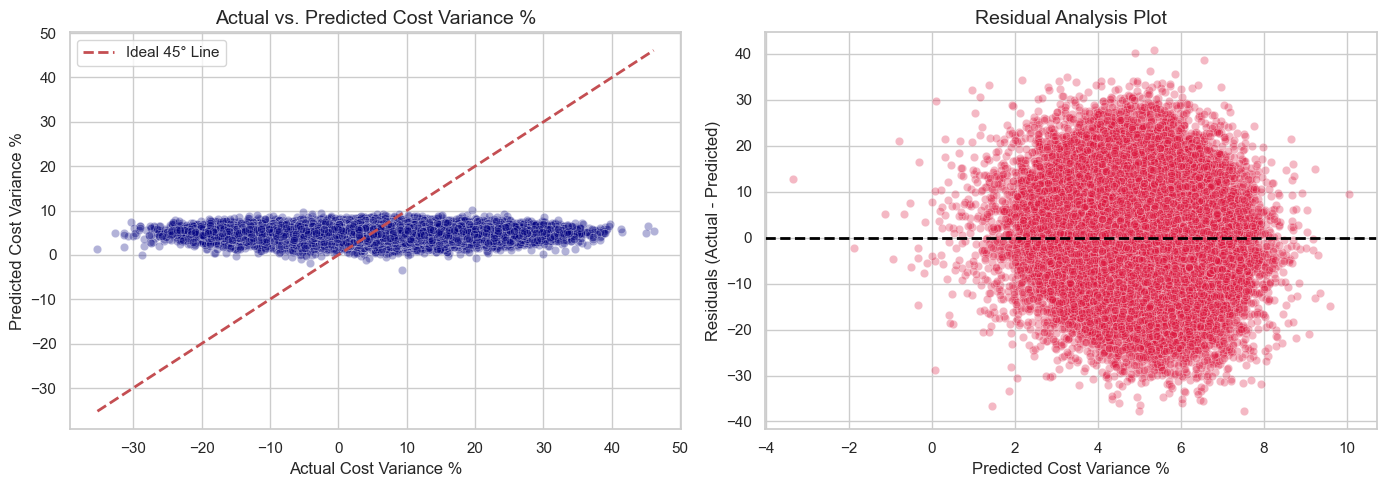

In [10]:
# =====================================================================
# TASK 4.2: PROJECT COST OVERRUN FORECASTING (CONTINUOUS REGRESSION)
# =====================================================================
print("\n=======================================================")
print("  TASK 4.2: PROJECT COST OVERRUN FORECASTING (REGRESSION)")
print("=======================================================")

# LinearSVR Scalability Configuration: dual="auto" for fast O(N) execution
svr_model = LinearSVR(dual="auto", loss="epsilon_insensitive", C=1.0, random_state=42)

# Neural Network & XGBoost Regressors configured with Huber / Absolute Error Loss
mlp_regressor = MLPRegressor(hidden_layer_sizes=(64, 32), loss='squared_error', max_iter=300, random_state=42)
xgb_regressor = XGBRegressor(n_estimators=100, max_depth=6, objective='reg:absoluteerror', learning_rate=0.1, random_state=42)
lin_regressor = LinearRegression()

# Voting Regressor Ensemble combining predictions using a soft average
voting_ensemble = VotingRegressor(estimators=[
    ('svr', svr_model),
    ('xgb', xgb_regressor),
    ('mlp', mlp_regressor),
    ('lr', lin_regressor)
])

cost_models = {
    'LinearSVR (Linear Fast)': svr_model,
    'Linear Regression': lin_regressor,
    'XGBoost Regressor (Huber/L1)': xgb_regressor,
    'MLP Regressor (Squared error)': mlp_regressor,
    'Voting Regressor Ensemble': voting_ensemble
}

# 5-Fold Standard K-Fold Cross-Validation
kf_cost = KFold(n_splits=5, shuffle=True, random_state=42)

cost_results = []
fig_cost, axes_cost = plt.subplots(1, 2, figsize=(14, 5))

for name, model in cost_models.items():
    oof_preds_cost = np.zeros(len(y_cost))
    
    for train_idx, val_idx in kf_cost.split(X_combined):
        X_tr, X_val = X_combined[train_idx], X_combined[val_idx]
        y_tr = y_cost[train_idx]
        
        model.fit(X_tr, y_tr)
        oof_preds_cost[val_idx] = model.predict(X_val)
        
    rmse = np.sqrt(mean_squared_error(y_cost, oof_preds_cost))
    r2 = r2_score(y_cost, oof_preds_cost)
    
    cost_results.append({'Model': name, 'RMSE': rmse, 'R2 Score': r2})
    print(f"[{name}] RMSE: {rmse:.4f} | R2 Score: {r2:.4f}")
    
    if name == 'Voting Regressor Ensemble':
        # Actual vs Predicted Scatter Plot
        sns.scatterplot(x=y_cost, y=oof_preds_cost, alpha=0.3, ax=axes_cost[0], color='navy')
        axes_cost[0].plot([y_cost.min(), y_cost.max()], [y_cost.min(), y_cost.max()], 'r--', lw=2, label='Ideal 45° Line')
        axes_cost[0].set_title("Actual vs. Predicted Cost Variance %")
        axes_cost[0].set_xlabel("Actual Cost Variance %")
        axes_cost[0].set_ylabel("Predicted Cost Variance %")
        axes_cost[0].legend()
        
        # Residual Plot
        residuals = y_cost - oof_preds_cost
        sns.scatterplot(x=oof_preds_cost, y=residuals, alpha=0.3, ax=axes_cost[1], color='crimson')
        axes_cost[1].axhline(0, color='black', linestyle='--', lw=2)
        axes_cost[1].set_title("Residual Analysis Plot")
        axes_cost[1].set_xlabel("Predicted Cost Variance %")
        axes_cost[1].set_ylabel("Residuals (Actual - Predicted)")

plt.tight_layout()
plt.show()

df_cost_summary = pd.DataFrame(cost_results)

#Interpretation: Low R2 and high RMSE indicate that there are no correlating features between the available features and cost pct. Hence cost cannot be predicted accurately with the given dataset

# Safety Incident Forecasting - Multi-Class Classification


  TASK 4.3: SAFETY INCIDENT FORECASTING (MULTI-CLASS)
[Random Forest Classifier] Macro Recall: 0.1243 | Macro F1: 0.1050 | Loss: 1.3010
[XGBoost Multi-Class] Macro Recall: 0.1245 | Macro F1: 0.1110 | Loss: 1.3612


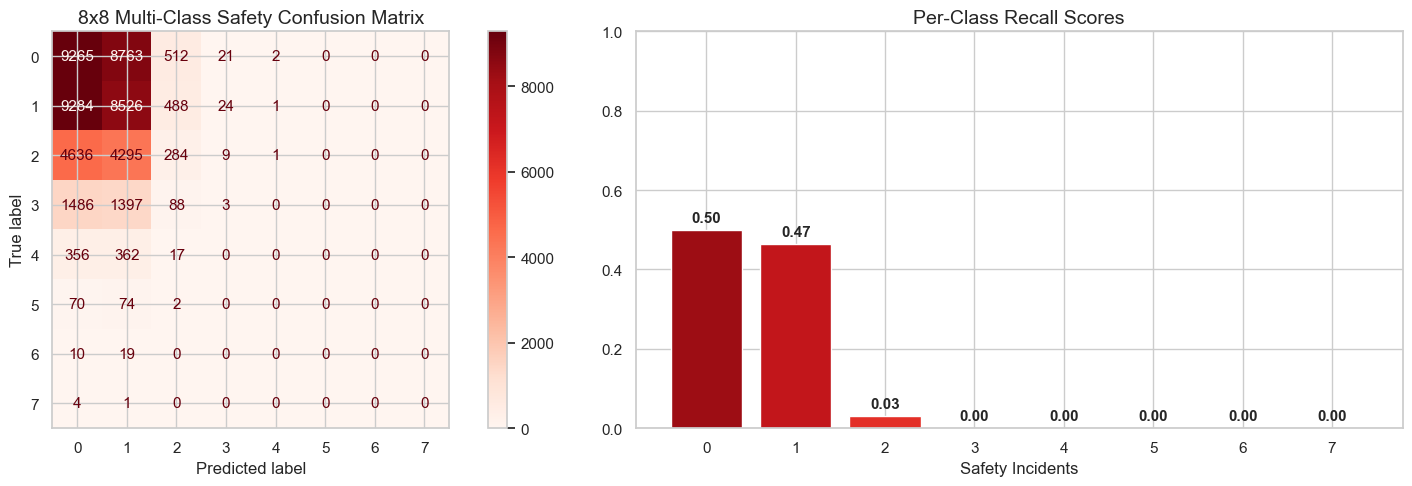

[Multinomial Logistic Regression] Macro Recall: 0.1243 | Macro F1: 0.1050 | Loss: 1.3021
[MLP Network (Multi-Class Softmax)] Macro Recall: 0.1246 | Macro F1: 0.1142 | Loss: 1.4617


In [11]:
# =====================================================================
# TASK 4.3: SAFETY INCIDENT FORECASTING (MULTI-CLASS CLASSIFICATION)
# =====================================================================
print("\n=======================================================")
print("  TASK 4.3: SAFETY INCIDENT FORECASTING (MULTI-CLASS)")
print("=======================================================")

n_safety_classes = int(y_safety.max()) + 1
safety_models = {
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost Multi-Class': XGBClassifier(n_estimators=100, max_depth=6, objective='multi:softprob', num_class=n_safety_classes, random_state=42),
    'Multinomial Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'MLP Network (Multi-Class Softmax)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
}

# 5-Fold Stratified Cross-Validation on Multi-Class Safety Target (classes 0..7)
skf_safety = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
safety_labels = [str(i) for i in range(n_safety_classes)]

safety_results = []

for name, model in safety_models.items():
    oof_preds_safety = np.zeros(len(y_safety))
    oof_probs_safety = np.zeros((len(y_safety), n_safety_classes))
    
    for train_idx, val_idx in skf_safety.split(X_combined, y_safety):
        X_tr, X_val = X_combined[train_idx], X_combined[val_idx]
        y_tr = y_safety[train_idx]
        
        model.fit(X_tr, y_tr)
        oof_preds_safety[val_idx] = model.predict(X_val)
        # Align predict_proba columns to full 0..7 class space
        probs = model.predict_proba(X_val)
        class_idx = {c: i for i, c in enumerate(model.classes_)}
        for c in range(n_safety_classes):
            if c in class_idx:
                oof_probs_safety[val_idx, c] = probs[:, class_idx[c]]
        
    macro_rec = recall_score(y_safety, oof_preds_safety, average='macro', labels=list(range(n_safety_classes)), zero_division=0)
    macro_f1 = f1_score(y_safety, oof_preds_safety, average='macro', labels=list(range(n_safety_classes)), zero_division=0)
    cat_loss = log_loss(y_safety, oof_probs_safety, labels=list(range(n_safety_classes)))
    
    safety_results.append({'Model': name, 'Macro Recall': macro_rec, 'Macro F1-Score': macro_f1, 'Categorical Loss': cat_loss})
    print(f"[{name}] Macro Recall: {macro_rec:.4f} | Macro F1: {macro_f1:.4f} | Loss: {cat_loss:.4f}")
    
    if name == 'XGBoost Multi-Class':
        fig_s, axes_s = plt.subplots(1, 2, figsize=(16, 5))
        # Must pass exactly n_safety_classes labels (8) to match ticks; do not use 4-bin labels
        ConfusionMatrixDisplay.from_predictions(
            y_safety,
            oof_preds_safety,
            labels=list(range(n_safety_classes)),
            display_labels=safety_labels,
            ax=axes_s[0],
            cmap='Reds',
            xticks_rotation=0,
        )
        axes_s[0].set_title(f"{n_safety_classes}x{n_safety_classes} Multi-Class Safety Confusion Matrix")

        # Per-Class Recall Bar Chart (explicit ticks avoid FixedLocator label mismatch)
        per_class_rec = recall_score(
            y_safety, oof_preds_safety,
            average=None,
            labels=list(range(n_safety_classes)),
            zero_division=0,
        )
        axes_s[1].bar(range(n_safety_classes), per_class_rec, color=sns.color_palette('Reds_r', n_safety_classes))
        axes_s[1].set_xticks(range(n_safety_classes))
        axes_s[1].set_xticklabels(safety_labels)
        axes_s[1].set_title("Per-Class Recall Scores")
        axes_s[1].set_xlabel("Safety Incidents")
        axes_s[1].set_ylim(0, 1.0)
        for i, v in enumerate(per_class_rec):
            axes_s[1].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
        plt.tight_layout()
        plt.show()

df_safety_summary = pd.DataFrame(safety_results)

#Interpretation: low recall and F1 indicate there is no feature correlation between the provided features and safety

# Operational PMO Routing Engine 

In [12]:
# =====================================================================
# STAGE 5: HOLDOUT EVALUATION WITH STAGE 4 BEST MODELS
# =====================================================================

# df_delay_summary / df_cost_summary / df_safety_summary exist in memory from previous stages.

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score,
)

print("=" * 70)
print("  STAGE 5.3: HOLDOUT TRAIN/TEST EVALUATION (STAGE 4 BEST MODELS)")
print("=" * 70)

# ---------------------------------------------------------------------
# A. Select Stage 4 CV winners
# ---------------------------------------------------------------------
best_delay_name = df_delay_summary.sort_values("F1-Score", ascending=False).iloc[0]["Model"]
best_cost_name = df_cost_summary.sort_values("RMSE", ascending=True).iloc[0]["Model"]
best_safety_name = df_safety_summary.sort_values("Macro F1-Score", ascending=False).iloc[0]["Model"]

print("Stage 4 best models selected for holdout retrain:")
print(f"  Delay:  {best_delay_name}")
print(f"  Cost:   {best_cost_name}")
print(f"  Safety: {best_safety_name}")

n_safety_classes_holdout = int(y_safety.max()) + 1

delay_registry = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
    ),
    "Gaussian Naive Bayes": GaussianNB(),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric="logloss",
    ),
}

cost_registry = {
    "LinearSVR (Linear Fast)": LinearSVR(
        dual="auto", loss="epsilon_insensitive", C=1.0, random_state=42
    ),
    "Linear Regression": LinearRegression(),
    "XGBoost Regressor (Huber/L1)": XGBRegressor(
        n_estimators=100, max_depth=6, objective="reg:absoluteerror",
        learning_rate=0.1, random_state=42,
    ),
    "MLP Regressor (Squared error)": MLPRegressor(
        hidden_layer_sizes=(64, 32), loss="squared_error", max_iter=300, random_state=42
    ),
    "Voting Regressor Ensemble": VotingRegressor(estimators=[
        ("svr", LinearSVR(dual="auto", loss="epsilon_insensitive", C=1.0, random_state=42)),
        ("xgb", XGBRegressor(
            n_estimators=100, max_depth=6, objective="reg:absoluteerror",
            learning_rate=0.1, random_state=42,
        )),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64, 32), loss="squared_error", max_iter=300, random_state=42
        )),
        ("lr", LinearRegression()),
    ]),
}

safety_registry = {
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ),
    "XGBoost Multi-Class": XGBClassifier(
        n_estimators=100, max_depth=6, objective="multi:softprob",
        num_class=n_safety_classes_holdout, random_state=42,
    ),
    "Multinomial Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "MLP Network (Multi-Class Softmax)": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=300, random_state=42
    ),
}

delay_estimator = clone(delay_registry[best_delay_name])
cost_estimator = clone(cost_registry[best_cost_name])
safety_estimator = clone(safety_registry[best_safety_name])

if best_delay_name == "XGBoost Classifier" and "search_xgb" in globals():
    delay_estimator.set_params(**search_xgb.best_params_)

# ---------------------------------------------------------------------
# B. 80/20 stratified split + leakage-safe preprocessing
# ---------------------------------------------------------------------
COST_OVERRUN_THRESHOLD = 5.0
RANDOM_STATE = 42
TEST_SIZE = 0.20

all_idx = np.arange(len(X))
train_idx, test_idx = train_test_split(
    all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_delay
)

X_train_raw = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
X_test_raw = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]

y_delay_train = y_delay[train_idx]
y_delay_test = y_delay[test_idx]
y_cost_train = y_cost[train_idx]
y_cost_test = y_cost[test_idx]
y_safety_train = y_safety[train_idx]
y_safety_test = y_safety[test_idx]
project_ids_test = df_engineered["project_id"].values[test_idx]

preprocessor_holdout = clone(preprocessor)
X_train_processed = preprocessor_holdout.fit_transform(X_train_raw)
X_test_processed = preprocessor_holdout.transform(X_test_raw)

print(f"\nHoldout split: train={len(train_idx):,} | test={len(test_idx):,}")
print(
    f"  Delay rate  train={y_delay_train.mean():.3f} | test={y_delay_test.mean():.3f}"
)

# ---------------------------------------------------------------------
# C. Train Stage-4-winning models; tune delay threshold on train only
# ---------------------------------------------------------------------
delay_estimator.fit(X_train_processed, y_delay_train)
cost_estimator.fit(X_train_processed, y_cost_train)
safety_estimator.fit(X_train_processed, y_safety_train)

train_delay_probs = delay_estimator.predict_proba(X_train_processed)[:, 1]
threshold_grid = np.arange(0.20, 0.61, 0.01)
train_f1_scores = [
    f1_score(y_delay_train, train_delay_probs >= t, zero_division=0)
    for t in threshold_grid
]
DECISION_THRESHOLD = float(threshold_grid[int(np.argmax(train_f1_scores))])
print(f"\nTrain-tuned delay decision threshold: {DECISION_THRESHOLD:.2f}")

delay_probabilities_test = delay_estimator.predict_proba(X_test_processed)[:, 1]
tuned_delay_risk_flags_test = (delay_probabilities_test >= DECISION_THRESHOLD).astype(int)
predicted_cost_variance_pct_test = cost_estimator.predict(X_test_processed)
tuned_safety_risk_values_test = safety_estimator.predict(X_test_processed)

# ---------------------------------------------------------------------
# D. PMO routing (cost-aware rules)
# ---------------------------------------------------------------------
def assign_pmo_routing(d_flag, c_var, s_val, cost_threshold=COST_OVERRUN_THRESHOLD):
    delay_risk = int(d_flag) == 1
    cost_risk = float(c_var) >= cost_threshold
    critical_safety = int(s_val) >= 2

    if delay_risk:
        return (
            "CRITICAL ALERT: Project may be delayed",
            "Authorize overtime acceleration pool; re-allocate crews from low-risk zones; "
            "freeze project change-order pipeline.",
        )
            
    if cost_risk and critical_safety:
        return (
            "MEDIUM RISK: Possible Safety & Financial Risk Overlap",
            "Mandate target site safety toolbox talks; freeze non-essential local purchasing; "
            "initiate on-site worker density capping audits.",
        )
    return (
        "LOW RISK: Standard Execution Tracking",
        "Maintain baseline project monitoring; track weekly milestone updates.",
    )

pred_pmo_strategies = []
pred_countermeasures = []
for d_flag, c_var, s_val in zip(
    tuned_delay_risk_flags_test,
    predicted_cost_variance_pct_test,
    tuned_safety_risk_values_test,
):
    strategy, countermeasure = assign_pmo_routing(d_flag, c_var, s_val)
    pred_pmo_strategies.append(strategy)
    pred_countermeasures.append(countermeasure)

actual_pmo_strategies = []
for d_flag, c_var, s_val in zip(y_delay_test, y_cost_test, y_safety_test):
    strategy, _ = assign_pmo_routing(d_flag, c_var, s_val)
    actual_pmo_strategies.append(strategy)

tier_match = np.array(pred_pmo_strategies) == np.array(actual_pmo_strategies)
tier_match_rate = tier_match.mean()

# ---------------------------------------------------------------------
# E. Layer 1 — per-head holdout metrics
# ---------------------------------------------------------------------
print("\n--- Layer 1: Per-Head Holdout Metrics ---")

delay_acc = accuracy_score(y_delay_test, tuned_delay_risk_flags_test)
delay_prec = precision_score(y_delay_test, tuned_delay_risk_flags_test, zero_division=0)
delay_rec = recall_score(y_delay_test, tuned_delay_risk_flags_test, zero_division=0)
delay_f1 = f1_score(y_delay_test, tuned_delay_risk_flags_test, zero_division=0)
delay_auc = roc_auc_score(y_delay_test, delay_probabilities_test)
delay_bce = log_loss(y_delay_test, delay_probabilities_test)

print(f"\n[Delay — {best_delay_name}]")
print(f"  Accuracy={delay_acc:.4f}  Precision={delay_prec:.4f}  Recall={delay_rec:.4f}")
print(f"  F1={delay_f1:.4f}  ROC-AUC={delay_auc:.4f}  BCE={delay_bce:.4f}")
print("  Confusion matrix:\n", confusion_matrix(y_delay_test, tuned_delay_risk_flags_test))

cost_rmse = np.sqrt(mean_squared_error(y_cost_test, predicted_cost_variance_pct_test))
cost_mae = mean_absolute_error(y_cost_test, predicted_cost_variance_pct_test)
cost_r2 = r2_score(y_cost_test, predicted_cost_variance_pct_test)
actual_overrun = (y_cost_test >= COST_OVERRUN_THRESHOLD).astype(int)
pred_overrun = (predicted_cost_variance_pct_test >= COST_OVERRUN_THRESHOLD).astype(int)

print(f"\n[Cost — {best_cost_name}]")
print(f"  RMSE={cost_rmse:.4f}  MAE={cost_mae:.4f}  R2={cost_r2:.4f}")
print(
    f"  Overrun flag (>= {COST_OVERRUN_THRESHOLD}%): "
    f"P={precision_score(actual_overrun, pred_overrun, zero_division=0):.4f}  "
    f"R={recall_score(actual_overrun, pred_overrun, zero_division=0):.4f}  "
    f"F1={f1_score(actual_overrun, pred_overrun, zero_division=0):.4f}"
)

safety_acc = accuracy_score(y_safety_test, tuned_safety_risk_values_test)
safety_macro_f1 = f1_score(
    y_safety_test, tuned_safety_risk_values_test,
    average="macro", labels=list(range(n_safety_classes_holdout)), zero_division=0,
)
safety_weighted_f1 = f1_score(
    y_safety_test, tuned_safety_risk_values_test, average="weighted", zero_division=0,
)

print(f"\n[Safety — {best_safety_name}]")
print(f"  Accuracy={safety_acc:.4f}  Macro-F1={safety_macro_f1:.4f}  Weighted-F1={safety_weighted_f1:.4f}")
print(classification_report(
    y_safety_test, tuned_safety_risk_values_test,
    labels=list(range(n_safety_classes_holdout)), zero_division=0,
))

# ---------------------------------------------------------------------
# F. Layer 2 — PMO tier calibration
# ---------------------------------------------------------------------
print("\n--- Layer 2: PMO Tier Calibration (predicted tier vs actual outcomes) ---")

df_calibration = pd.DataFrame({
    "Predicted_PMO_Tier": pred_pmo_strategies,
    "Actual_Delay_Rate": y_delay_test,
    "Actual_Cost_Variance_Pct": y_cost_test,
    "Actual_Safety_Incidents": y_safety_test,
})

tier_calibration = (
    df_calibration.groupby("Predicted_PMO_Tier", as_index=False)
    .agg(
        Project_Count=("Actual_Delay_Rate", "size"),
        Actual_Delay_Rate_Mean=("Actual_Delay_Rate", "mean"),
        Actual_Cost_Variance_Mean=("Actual_Cost_Variance_Pct", "mean"),
        Actual_Safety_Incidents_Mean=("Actual_Safety_Incidents", "mean"),
    )
    .sort_values("Actual_Delay_Rate_Mean", ascending=False)
)
display(tier_calibration)

# ---------------------------------------------------------------------
# G. Layer 3 — predicted vs actual PMO tier agreement
# ---------------------------------------------------------------------
print("\n--- Layer 3: PMO Tier Agreement ---")
print(f"  Tier exact-match rate: {tier_match_rate:.4f} ({tier_match.sum():,}/{len(tier_match):,})")

tier_confusion = pd.crosstab(
    pd.Series(actual_pmo_strategies, name="Actual_PMO_Tier"),
    pd.Series(pred_pmo_strategies, name="Predicted_PMO_Tier"),
)
print("\n  Tier confusion matrix (rows=actual, cols=predicted):")
display(tier_confusion)

print("\nNOTE: Stage 4 metrics are OOF/CV on full 50k with full-data preprocessing.")
print("      Stage 5 metrics are true holdout on 20% test — use these for honest evaluation.")
print(f"      Models: delay={best_delay_name}, cost={best_cost_name}, safety={best_safety_name}")
print(f"      Delay threshold (train-tuned): {DECISION_THRESHOLD:.2f}")

if "best_run" in globals():
    print(f"      Stage 4.2b leakage-safe delay threshold (reference): {best_run.get('threshold', 'n/a')}")

# ---------------------------------------------------------------------
# H. Export holdout ledger + metrics CSVs
# ---------------------------------------------------------------------
data_output_dir = "data"
os.makedirs(data_output_dir, exist_ok=True)

df_holdout_eval = pd.DataFrame({
    "Project_ID": project_ids_test,
    "Dataset_Split": "test_holdout",
    "Delay_Model_Used": best_delay_name,
    "Cost_Model_Used": best_cost_name,
    "Safety_Model_Used": best_safety_name,
    "Delay_Probability": np.round(delay_probabilities_test, 4),
    "Delay_Decision_Threshold": DECISION_THRESHOLD,
    "Predicted_Delay_Risk_Flag": tuned_delay_risk_flags_test,
    "Actual_Delay_Risk_Flag": y_delay_test,
    "Predicted_Cost_Variance_Pct": np.round(predicted_cost_variance_pct_test, 2),
    "Actual_Cost_Variance_Pct": np.round(y_cost_test, 2),
    "Predicted_Safety_Risk_Value": tuned_safety_risk_values_test,
    "Actual_Safety_Incidents": y_safety_test,
    "Predicted_PMO_Tier": pred_pmo_strategies,
    "Actual_PMO_Tier": actual_pmo_strategies,
    "PMO_Tier_Match": tier_match.astype(int),
    "Targeted_Operational_Countermeasure": pred_countermeasures,
})

df_holdout_ledger = df_holdout_eval[[
    "Project_ID", "Dataset_Split", "Delay_Model_Used", "Cost_Model_Used",
    "Safety_Model_Used", "Predicted_Delay_Risk_Flag", "Predicted_Cost_Variance_Pct",
    "Predicted_Safety_Risk_Value", "Predicted_PMO_Tier",
    "Targeted_Operational_Countermeasure",
]]

metrics_rows = [
    {"metric_group": "model_selection", "metric_name": "delay_model", "metric_value": best_delay_name},
    {"metric_group": "model_selection", "metric_name": "cost_model", "metric_value": best_cost_name},
    {"metric_group": "model_selection", "metric_name": "safety_model", "metric_value": best_safety_name},
    {"metric_group": "model_selection", "metric_name": "delay_threshold", "metric_value": DECISION_THRESHOLD},
    {"metric_group": "delay", "metric_name": "accuracy", "metric_value": delay_acc},
    {"metric_group": "delay", "metric_name": "precision", "metric_value": delay_prec},
    {"metric_group": "delay", "metric_name": "recall", "metric_value": delay_rec},
    {"metric_group": "delay", "metric_name": "f1", "metric_value": delay_f1},
    {"metric_group": "delay", "metric_name": "roc_auc", "metric_value": delay_auc},
    {"metric_group": "delay", "metric_name": "bce", "metric_value": delay_bce},
    {"metric_group": "cost", "metric_name": "rmse", "metric_value": cost_rmse},
    {"metric_group": "cost", "metric_name": "mae", "metric_value": cost_mae},
    {"metric_group": "cost", "metric_name": "r2", "metric_value": cost_r2},
    {"metric_group": "cost", "metric_name": "overrun_precision", "metric_value": precision_score(actual_overrun, pred_overrun, zero_division=0)},
    {"metric_group": "cost", "metric_name": "overrun_recall", "metric_value": recall_score(actual_overrun, pred_overrun, zero_division=0)},
    {"metric_group": "cost", "metric_name": "overrun_f1", "metric_value": f1_score(actual_overrun, pred_overrun, zero_division=0)},
    {"metric_group": "safety", "metric_name": "accuracy", "metric_value": safety_acc},
    {"metric_group": "safety", "metric_name": "macro_f1", "metric_value": safety_macro_f1},
    {"metric_group": "safety", "metric_name": "weighted_f1", "metric_value": safety_weighted_f1},
    {"metric_group": "pmo_tier", "metric_name": "tier_match_rate", "metric_value": tier_match_rate},
]

df_metrics_summary = pd.DataFrame(metrics_rows)

paths = {
    "ledger": os.path.join(data_output_dir, "buildmax_pmo_holdout_test_ledger.csv"),
    "eval": os.path.join(data_output_dir, "buildmax_holdout_evaluation_summary.csv"),
    "metrics": os.path.join(data_output_dir, "buildmax_holdout_metrics_summary.csv"),
    "calibration": os.path.join(data_output_dir, "buildmax_holdout_tier_calibration.csv"),
}

df_holdout_ledger.to_csv(paths["ledger"], index=False)
df_holdout_eval.to_csv(paths["eval"], index=False)
df_metrics_summary.to_csv(paths["metrics"], index=False)
tier_calibration.to_csv(paths["calibration"], index=False)

print("\n--- Exported files ---")
for label, path in paths.items():
    print(f"  {label}: {path}")

print(f"\nHoldout ledger rows: {len(df_holdout_ledger):,}")
print("\n--- Predicted PMO Tier Breakdown (test set) ---")
print(df_holdout_ledger["Predicted_PMO_Tier"].value_counts())
print("\nStage 5 complete.")

  STAGE 5.3: HOLDOUT TRAIN/TEST EVALUATION (STAGE 4 BEST MODELS)
Stage 4 best models selected for holdout retrain:
  Delay:  XGBoost Classifier
  Cost:   Linear Regression
  Safety: MLP Network (Multi-Class Softmax)

Holdout split: train=40,000 | test=10,000
  Delay rate  train=0.216 | test=0.216

Train-tuned delay decision threshold: 0.38

--- Layer 1: Per-Head Holdout Metrics ---

[Delay — XGBoost Classifier]
  Accuracy=0.8469  Precision=0.6488  Recall=0.6347
  F1=0.6417  ROC-AUC=0.8851  BCE=0.3281
  Confusion matrix:
 [[7098  742]
 [ 789 1371]]

[Cost — Linear Regression]
  RMSE=9.9653  MAE=7.9495  R2=-0.0019
  Overrun flag (>= 5.0%): P=0.5083  R=0.4495  F1=0.4771

[Safety — MLP Network (Multi-Class Softmax)]
  Accuracy=0.3587  Macro-F1=0.1128  Weighted-F1=0.3223
              precision    recall  f1-score   support

           0       0.37      0.47      0.42      3743
           1       0.37      0.47      0.41      3704
           2       0.14      0.05      0.07      1782
      

,Predicted_PMO_Tier,Project_Count,Actual_Delay_Rate_Mean,Actual_Cost_Variance_Mean,Actual_Safety_Incidents_Mean
0,CRITICAL ALERT: Project may be delayed,2113,0.648841,5.216175,1.025556
2,MEDIUM RISK: Possible Safety & Financial Risk ...,230,0.108696,4.496115,0.921739
1,LOW RISK: Standard Execution Tracking,7657,0.099778,5.311783,0.968395



--- Layer 3: PMO Tier Agreement ---
  Tier exact-match rate: 0.7440 (7,440/10,000)

  Tier confusion matrix (rows=actual, cols=predicted):


Predicted_PMO_Tier,CRITICAL ALERT: Project may be delayed,LOW RISK: Standard Execution Tracking,MEDIUM RISK: Possible Safety & Financial Risk Overlap
Actual_PMO_Tier,,,
CRITICAL ALERT: Project may be delayed,1371,764,25
LOW RISK: Standard Execution Tracking,653,6053,189
MEDIUM RISK: Possible Safety & Financial Risk Overlap,89,840,16



NOTE: Stage 4 metrics are OOF/CV on full 50k with full-data preprocessing.
      Stage 5 metrics are true holdout on 20% test — use these for honest evaluation.
      Models: delay=XGBoost Classifier, cost=Linear Regression, safety=MLP Network (Multi-Class Softmax)
      Delay threshold (train-tuned): 0.38
      Stage 4.2b leakage-safe delay threshold (reference): 0.304

--- Exported files ---
  ledger: data\buildmax_pmo_holdout_test_ledger.csv
  eval: data\buildmax_holdout_evaluation_summary.csv
  metrics: data\buildmax_holdout_metrics_summary.csv
  calibration: data\buildmax_holdout_tier_calibration.csv

Holdout ledger rows: 10,000

--- Predicted PMO Tier Breakdown (test set) ---
Predicted_PMO_Tier
LOW RISK: Standard Execution Tracking                    7657
CRITICAL ALERT: Project may be delayed                   2113
MEDIUM RISK: Possible Safety & Financial Risk Overlap     230
Name: count, dtype: int64

Stage 5 complete.
